# BN-xG: Bayesian Network Expected Goals Model from StatsBomb Open Data

This notebook builds an expected-goals model from StatsBomb shot event data. The target probability is



1. load and clean shot-level data;
2. engineer shot geometry, goalkeeper, pressure, and shot-triangle features;
3. perform exploratory data analysis;
4. analyze feature importance with Random Forest;
5. build a Logistic Regression xG baseline;
6. build an expert-designed Bayesian Network;
7. learn a Bayesian Network structure with Hill-Climbing;
8. run exact inference with Variable Elimination;
9. compare Logistic xG, Expert BN-xG, Hill-Climbing BN-xG, and StatsBomb xG as an external benchmark.

StatsBomb xG is **not used for training**. It is used only at the end as an external benchmark for comparison.


## Notebook Structure

- **Environment and data loading**: imports, theme, dataset loading, target preparation.
- **Feature engineering**: shot geometry, goalkeeper context, player pressure, and shot-triangle features.
- **Exploratory analysis**: descriptive tables, temporal trends, pitch-section heat maps, and goal-rate dashboards.
- **Machine-learning baselines**: Random Forest feature importance and Logistic Regression xG baseline.
- **Bayesian Network modeling**: expert structure, learned Hill-Climbing structure, CPT learning, and exact inference.
- **Model comparison and interpretation**: probability metrics, external StatsBomb xG benchmark, calibration, and final notes.


## Environment and Visual Theme

This section imports the required libraries and defines the shared white academic visualization style used throughout the notebook.

In [1]:
# Environment and Visual Theme
import os
import json
import ast
import textwrap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

os.makedirs("figures", exist_ok=True)

# ------------------------------------------------------------
# White academic theme colors
# ------------------------------------------------------------

BG      = "#ffffff"
PANEL   = "#f8fafc"
GRID    = "#dbe4ee"
TEXT    = "#0f172a"
SUBTEXT = "#475569"
BORDER  = "#cbd5e1"

GREEN  = "#22c55e"
GOLD   = "#facc15"
BLUE   = "#38bdf8"
PINK   = "#f472b6"
PURPLE = "#a78bfa"
RED    = "#ef4444"
ORANGE = "#fb923c"
NAVY   = "#1e3a8a"
CYAN   = "#06b6d4"
GRAY   = "#94a3b8"

GOAL_COLOR = GREEN
NONGOAL_COLOR = GRAY

CMAP_BLUE = LinearSegmentedColormap.from_list(
    "white_blue",
    ["#ffffff", "#dbeafe", BLUE, NAVY]
)

CMAP_GREEN = LinearSegmentedColormap.from_list(
    "white_green",
    ["#ffffff", "#dcfce7", GREEN, "#166534"]
)

PITCH_GREEN_CMAP = LinearSegmentedColormap.from_list(
    "pitch_green_heatmap",
    ["#f7fff7", "#dcfce7", "#86efac", "#22c55e", "#15803d", "#064e3b"]
)

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "savefig.facecolor": BG,
    "axes.edgecolor": BORDER,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": SUBTEXT,
    "ytick.color": SUBTEXT,
    "text.color": TEXT,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.75,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.facecolor": BG,
    "legend.edgecolor": BORDER,
    "legend.framealpha": 0.95,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def style_axis(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(PANEL)
    ax.grid(True, zorder=0)
    ax.set_axisbelow(True)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(BORDER)
        ax.spines[spine].set_linewidth(1.0)

    if title:
        ax.set_title(title, fontsize=16, fontweight="bold", color=TEXT, pad=16)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, color=TEXT, labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, color=TEXT, labelpad=8)

    return ax

def save_fig(filename):
    plt.savefig(filename, dpi=180, bbox_inches="tight", facecolor=BG)
    print(f"Saved figure: {filename}")

print("Imports and visual theme loaded successfully.")


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Imports and visual theme loaded successfully.


## Load Shot-Level Dataset

This notebook expects a shot-level CSV file. Update `SHOTS_CSV_PATH` if your file is located somewhere else.

The expected dataset contains one row per shot.

In [2]:
# Load Shot-Level Dataset
SHOTS_CSV_PATH = "/Users/farzammanafzadeh/Desktop/Module 3 FAKIR Project/StatsBomb/shots_cleaned.csv"

shots_df = pd.read_csv(SHOTS_CSV_PATH)

print("Dataset loaded successfully.")
print("Shape:", shots_df.shape)

display(shots_df.head())


Dataset loaded successfully.
Shape: (108281, 22)


,shot_id,match_id,period,minute,second,team,possession_team,play_pattern,position,x,y,statsbomb_xg,shot_outcome,body_part,technique,shot_type,first_time,one_on_one,open_goal,freeze_frame,under_pressure,goal
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,15946,1,2,29,Barcelona,Barcelona,From Throw In,Left Center Forward,111.5,52.9,0.076992,Off T,Right Foot,Half Volley,Open Play,True,False,False,"[{'location': [91.1, 50.2], 'player': {'id': 6...",False,0
1,9107d374-2942-4876-a14f-1b9f86901c15,15946,1,5,39,Barcelona,Barcelona,Regular Play,Left Back,113.9,26.4,0.051668,Off T,Left Foot,Volley,Open Play,True,False,False,"[{'location': [108.1, 36.8], 'player': {'id': ...",False,0
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,15946,1,15,29,Barcelona,Barcelona,From Keeper,Left Center Forward,93.7,34.7,0.016932,Saved,Left Foot,Normal,Open Play,False,False,False,"[{'location': [95.3, 35.2], 'player': {'id': 6...",False,0
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,15946,1,16,20,Deportivo Alavés,Deportivo Alavés,Regular Play,Center Forward,109.2,39.1,0.122604,Off T,Head,Normal,Open Play,False,False,False,"[{'location': [102.8, 31.5], 'player': {'id': ...",True,0
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,15946,1,18,16,Barcelona,Barcelona,From Corner,Right Center Forward,107.8,24.7,0.041751,Off T,Right Foot,Normal,Open Play,False,False,False,"[{'location': [109.0, 27.2], 'player': {'id': ...",False,0


## Target Variable and Column Standardization

This section standardizes the target variable.

The target is:

- `goal = 1`: the shot became a goal;
- `goal = 0`: the shot did not become a goal.

If `goal` is not already available, it is created from `shot_outcome`.

In [3]:
# Target Variable and Column Standardization
# Create goal target if needed
if "goal" not in shots_df.columns:
    if "shot_outcome" not in shots_df.columns:
        raise ValueError("Neither 'goal' nor 'shot_outcome' exists. Cannot create target variable.")
    shots_df["goal"] = (shots_df["shot_outcome"].astype(str) == "Goal").astype(int)

shots_df["goal"] = shots_df["goal"].astype(int)

# Create shot_id if needed
if "shot_id" not in shots_df.columns and "id" in shots_df.columns:
    shots_df["shot_id"] = shots_df["id"]

# Ensure numeric columns
for col in ["minute", "second", "x", "y", "statsbomb_xg"]:
    if col in shots_df.columns:
        shots_df[col] = pd.to_numeric(shots_df[col], errors="coerce")

print("Target variable prepared.")
print("Total shots:", len(shots_df))
print("Total goals:", int(shots_df["goal"].sum()))
print("Goal rate:", f"{shots_df['goal'].mean():.2%}")

display(shots_df.head())


Target variable prepared.
Total shots: 108281
Total goals: 12084
Goal rate: 11.16%


,shot_id,match_id,period,minute,second,team,possession_team,play_pattern,position,x,y,statsbomb_xg,shot_outcome,body_part,technique,shot_type,first_time,one_on_one,open_goal,freeze_frame,under_pressure,goal
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,15946,1,2,29,Barcelona,Barcelona,From Throw In,Left Center Forward,111.5,52.9,0.076992,Off T,Right Foot,Half Volley,Open Play,True,False,False,"[{'location': [91.1, 50.2], 'player': {'id': 6...",False,0
1,9107d374-2942-4876-a14f-1b9f86901c15,15946,1,5,39,Barcelona,Barcelona,Regular Play,Left Back,113.9,26.4,0.051668,Off T,Left Foot,Volley,Open Play,True,False,False,"[{'location': [108.1, 36.8], 'player': {'id': ...",False,0
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,15946,1,15,29,Barcelona,Barcelona,From Keeper,Left Center Forward,93.7,34.7,0.016932,Saved,Left Foot,Normal,Open Play,False,False,False,"[{'location': [95.3, 35.2], 'player': {'id': 6...",False,0
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,15946,1,16,20,Deportivo Alavés,Deportivo Alavés,Regular Play,Center Forward,109.2,39.1,0.122604,Off T,Head,Normal,Open Play,False,False,False,"[{'location': [102.8, 31.5], 'player': {'id': ...",True,0
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,15946,1,18,16,Barcelona,Barcelona,From Corner,Right Center Forward,107.8,24.7,0.041751,Off T,Right Foot,Normal,Open Play,False,False,False,"[{'location': [109.0, 27.2], 'player': {'id': ...",False,0


## Freeze-Frame and Location Parsing

StatsBomb freeze-frame fields may be stored as real Python lists or as strings that look like lists.

This section safely parses:

- `freeze_frame`;
- goalkeeper location;
- teammate locations;
- opponent locations.

In [4]:
# Freeze-Frame and Location Parsing
def parse_if_string(value):
    if isinstance(value, (dict, list)):
        return value
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return value
    return value

def parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

def extract_gk_location(freeze_frame):
    freeze_frame = parse_list(freeze_frame)
    for player_obj in freeze_frame:
        if not isinstance(player_obj, dict):
            continue

        position = player_obj.get("position", {})
        position_name = position.get("name") if isinstance(position, dict) else None
        teammate = player_obj.get("teammate")
        location = player_obj.get("location")

        if position_name == "Goalkeeper" and teammate is False:
            if isinstance(location, list) and len(location) >= 2:
                return location

    return [np.nan, np.nan]

def extract_teammate_locations(freeze_frame):
    freeze_frame = parse_list(freeze_frame)
    locations = []

    for player_obj in freeze_frame:
        if not isinstance(player_obj, dict):
            continue

        if player_obj.get("teammate") is True:
            loc = player_obj.get("location")
            if isinstance(loc, list) and len(loc) >= 2:
                locations.append(loc)

    return locations

def extract_opponent_locations(freeze_frame, include_goalkeeper=True):
    freeze_frame = parse_list(freeze_frame)
    locations = []

    for player_obj in freeze_frame:
        if not isinstance(player_obj, dict):
            continue

        teammate = player_obj.get("teammate")
        loc = player_obj.get("location")
        position = player_obj.get("position", {})
        position_name = position.get("name") if isinstance(position, dict) else None

        if teammate is False and isinstance(loc, list) and len(loc) >= 2:
            if include_goalkeeper:
                locations.append(loc)
            else:
                if position_name != "Goalkeeper":
                    locations.append(loc)

    return locations

# Parse freeze-frame if present
if "freeze_frame" in shots_df.columns:
    shots_df["freeze_frame"] = shots_df["freeze_frame"].apply(parse_list)

    if "gk_location" not in shots_df.columns:
        shots_df["gk_location"] = shots_df["freeze_frame"].apply(extract_gk_location)

    if "teammate_locations" not in shots_df.columns:
        shots_df["teammate_locations"] = shots_df["freeze_frame"].apply(extract_teammate_locations)

    if "opponent_locations" not in shots_df.columns:
        shots_df["opponent_locations"] = shots_df["freeze_frame"].apply(
            lambda ff: extract_opponent_locations(ff, include_goalkeeper=True)
        )

    if "opponent_locations_without_gk" not in shots_df.columns:
        shots_df["opponent_locations_without_gk"] = shots_df["freeze_frame"].apply(
            lambda ff: extract_opponent_locations(ff, include_goalkeeper=False)
        )

# Parse existing list columns if already available
for col in ["gk_location", "teammate_locations", "opponent_locations", "opponent_locations_without_gk"]:
    if col in shots_df.columns:
        shots_df[col] = shots_df[col].apply(parse_list)

# Extract GK x/y if needed
if "gk_location" in shots_df.columns:
    if "gk_x" not in shots_df.columns:
        shots_df["gk_x"] = shots_df["gk_location"].apply(lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 2 else np.nan)
    if "gk_y" not in shots_df.columns:
        shots_df["gk_y"] = shots_df["gk_location"].apply(lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else np.nan)

# Visible player counts
if "teammate_locations" in shots_df.columns:
    shots_df["num_teammates_visible"] = shots_df["teammate_locations"].apply(lambda x: len(parse_list(x)))

if "opponent_locations" in shots_df.columns:
    shots_df["num_opponents_visible"] = shots_df["opponent_locations"].apply(lambda x: len(parse_list(x)))

if "opponent_locations_without_gk" in shots_df.columns:
    shots_df["num_opponents_without_gk_visible"] = shots_df["opponent_locations_without_gk"].apply(lambda x: len(parse_list(x)))

print("Freeze-frame and location columns parsed successfully.")
display(shots_df.head())


Freeze-frame and location columns parsed successfully.


,shot_id,match_id,period,minute,second,team,possession_team,play_pattern,position,x,y,statsbomb_xg,shot_outcome,body_part,technique,shot_type,first_time,one_on_one,open_goal,freeze_frame,under_pressure,goal,gk_location,teammate_locations,opponent_locations,opponent_locations_without_gk,gk_x,gk_y,num_teammates_visible,num_opponents_visible,num_opponents_without_gk_visible
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,15946,1,2,29,Barcelona,Barcelona,From Throw In,Left Center Forward,111.5,52.9,0.076992,Off T,Right Foot,Half Volley,Open Play,True,False,False,"[{'location': [91.1, 50.2], 'player': {'id': 6...",False,0,"[116.5, 45.6]","[[103.0, 44.8], [95.4, 53.4], [95.6, 25.4]]","[[91.1, 50.2], [93.2, 43.7], [82.9, 59.5], [10...","[[91.1, 50.2], [93.2, 43.7], [82.9, 59.5], [10...",116.5,45.6,3,8,7
1,9107d374-2942-4876-a14f-1b9f86901c15,15946,1,5,39,Barcelona,Barcelona,Regular Play,Left Back,113.9,26.4,0.051668,Off T,Left Foot,Volley,Open Play,True,False,False,"[{'location': [108.1, 36.8], 'player': {'id': ...",False,0,"[118.8, 36.7]","[[86.4, 51.6], [91.9, 36.7], [98.0, 65.0], [98...","[[108.1, 36.8], [95.5, 50.8], [98.8, 42.0], [9...","[[108.1, 36.8], [95.5, 50.8], [98.8, 42.0], [9...",118.8,36.7,7,10,9
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,15946,1,15,29,Barcelona,Barcelona,From Keeper,Left Center Forward,93.7,34.7,0.016932,Saved,Left Foot,Normal,Open Play,False,False,False,"[{'location': [95.3, 35.2], 'player': {'id': 6...",False,0,"[117.6, 38.9]","[[89.0, 34.9], [86.7, 21.7], [84.4, 24.7], [10...","[[95.3, 35.2], [88.6, 36.9], [84.2, 51.7], [10...","[[95.3, 35.2], [88.6, 36.9], [84.2, 51.7], [10...",117.6,38.9,7,9,8
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,15946,1,16,20,Deportivo Alavés,Deportivo Alavés,Regular Play,Center Forward,109.2,39.1,0.122604,Off T,Head,Normal,Open Play,False,False,False,"[{'location': [102.8, 31.5], 'player': {'id': ...",True,0,"[117.6, 39.0]","[[102.8, 31.5], [102.9, 25.9], [98.1, 15.3]]","[[103.8, 20.8], [117.6, 39.0], [96.1, 33.7], [...","[[103.8, 20.8], [96.1, 33.7], [94.6, 24.8], [9...",117.6,39.0,3,8,7
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,15946,1,18,16,Barcelona,Barcelona,From Corner,Right Center Forward,107.8,24.7,0.041751,Off T,Right Foot,Normal,Open Play,False,False,False,"[{'location': [109.0, 27.2], 'player': {'id': ...",False,0,"[117.6, 37.4]","[[98.0, 30.8], [89.9, 51.0], [113.2, 39.5], [1...","[[109.0, 27.2], [111.5, 39.5], [110.7, 35.0], ...","[[109.0, 27.2], [111.5, 39.5], [110.7, 35.0], ...",117.6,37.4,7,11,10


## Shot Geometry Features

Expected-goals models usually rely heavily on shot geometry.

This section creates:

- `distance_to_goal`: distance from the shot to the goal center;
- `shot_angle`: angle between the shooter and the two goalposts.

In [5]:
# Shot Geometry Features
GOAL_CENTER_X = 120
GOAL_CENTER_Y = 40

LEFT_POST = np.array([120, 36])
RIGHT_POST = np.array([120, 44])

def calculate_distance_to_goal(x, y):
    if pd.isna(x) or pd.isna(y):
        return np.nan
    return np.sqrt((GOAL_CENTER_X - x) ** 2 + (GOAL_CENTER_Y - y) ** 2)

def calculate_shot_angle(x, y):
    if pd.isna(x) or pd.isna(y):
        return np.nan

    shot_location = np.array([x, y])
    vector_left = LEFT_POST - shot_location
    vector_right = RIGHT_POST - shot_location

    norm_left = np.linalg.norm(vector_left)
    norm_right = np.linalg.norm(vector_right)

    if norm_left == 0 or norm_right == 0:
        return np.nan

    cosine_angle = np.dot(vector_left, vector_right) / (norm_left * norm_right)
    cosine_angle = np.clip(cosine_angle, -1, 1)

    return np.degrees(np.arccos(cosine_angle))

if "distance_to_goal" not in shots_df.columns:
    shots_df["distance_to_goal"] = shots_df.apply(
        lambda row: calculate_distance_to_goal(row["x"], row["y"]),
        axis=1
    )

if "shot_angle" not in shots_df.columns:
    shots_df["shot_angle"] = shots_df.apply(
        lambda row: calculate_shot_angle(row["x"], row["y"]),
        axis=1
    )

display(shots_df[["x", "y", "distance_to_goal", "shot_angle", "goal"]].head())
display(shots_df[["distance_to_goal", "shot_angle"]].describe())


,x,y,distance_to_goal,shot_angle,goal
0,111.5,52.9,15.448625,16.982586,0
1,113.9,26.4,14.905368,13.316706,0
2,93.7,34.7,26.828716,16.644406,0
3,109.2,39.1,10.837435,40.419411,0
4,107.8,24.7,19.568597,14.895257,0


,distance_to_goal,shot_angle
count,108281.000000,108281.000000
mean,18.994966,25.738296
std,8.740689,15.974636
min,0.400000,0.000000
25%,11.987076,15.172915
50%,18.200275,20.072588
75%,25.211505,32.067392
max,92.800862,180.000000


## Goalkeeper Context Features

The goalkeeper's position can strongly affect scoring probability.

This section creates:

- `gk_available`;
- `gk_distance_to_goal`;
- `distance_to_gk`.

In [6]:
# Goalkeeper Context Features
def euclidean_distance(x1, y1, x2, y2):
    if pd.isna(x1) or pd.isna(y1) or pd.isna(x2) or pd.isna(y2):
        return np.nan
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

if "gk_x" in shots_df.columns and "gk_y" in shots_df.columns:
    shots_df["gk_available"] = shots_df["gk_x"].notna() & shots_df["gk_y"].notna()

    if "gk_distance_to_goal" not in shots_df.columns:
        shots_df["gk_distance_to_goal"] = shots_df.apply(
            lambda row: euclidean_distance(row["gk_x"], row["gk_y"], GOAL_CENTER_X, GOAL_CENTER_Y),
            axis=1
        )

    if "distance_to_gk" not in shots_df.columns:
        shots_df["distance_to_gk"] = shots_df.apply(
            lambda row: euclidean_distance(row["x"], row["y"], row["gk_x"], row["gk_y"]),
            axis=1
        )
else:
    shots_df["gk_available"] = False
    shots_df["gk_distance_to_goal"] = np.nan
    shots_df["distance_to_gk"] = np.nan

display(shots_df[["gk_available", "gk_distance_to_goal", "distance_to_gk"]].describe(include="all"))


,gk_available,gk_distance_to_goal,distance_to_gk
count,108281,106802.000000,106802.000000
unique,2,NaN,NaN
top,True,NaN,NaN
freq,106802,NaN,NaN
mean,NaN,3.300535,16.104442
std,NaN,2.557350,8.902316
min,NaN,0.000000,0.316228
25%,NaN,1.824829,8.765843
50%,NaN,2.778489,14.940214
75%,NaN,3.962323,22.727076


## Nearby Player Pressure Features

The freeze-frame data contains visible teammates and opponents at shot time.

This section creates pressure features such as:

- opponents near the shooter;
- teammates near the shooter;
- nearest opponent distance;
- nearest teammate distance.

In [7]:
# Nearby Player Pressure Features
def distance_from_shooter_to_locations(shooter_x, shooter_y, locations):
    locations = parse_list(locations)
    distances = []

    if pd.isna(shooter_x) or pd.isna(shooter_y):
        return distances

    for loc in locations:
        if isinstance(loc, list) and len(loc) >= 2:
            px, py = loc[0], loc[1]
            if not pd.isna(px) and not pd.isna(py):
                distances.append(np.sqrt((shooter_x - px) ** 2 + (shooter_y - py) ** 2))

    return distances

def count_players_within_radius(shooter_x, shooter_y, locations, radius):
    distances = distance_from_shooter_to_locations(shooter_x, shooter_y, locations)
    return sum(dist <= radius for dist in distances)

def nearest_player_distance(shooter_x, shooter_y, locations):
    distances = distance_from_shooter_to_locations(shooter_x, shooter_y, locations)
    return np.nan if len(distances) == 0 else min(distances)

# Ensure location columns exist
if "teammate_locations" not in shots_df.columns:
    shots_df["teammate_locations"] = [[] for _ in range(len(shots_df))]
if "opponent_locations_without_gk" not in shots_df.columns:
    shots_df["opponent_locations_without_gk"] = [[] for _ in range(len(shots_df))]

shots_df["num_opponents_near_shooter_1m"] = shots_df.apply(
    lambda row: count_players_within_radius(row["x"], row["y"], row["opponent_locations_without_gk"], radius=1),
    axis=1
)

shots_df["num_opponents_near_shooter_2m"] = shots_df.apply(
    lambda row: count_players_within_radius(row["x"], row["y"], row["opponent_locations_without_gk"], radius=2),
    axis=1
)

shots_df["num_teammates_near_shooter_2m"] = shots_df.apply(
    lambda row: count_players_within_radius(row["x"], row["y"], row["teammate_locations"], radius=2),
    axis=1
)

shots_df["nearest_opponent_distance"] = shots_df.apply(
    lambda row: nearest_player_distance(row["x"], row["y"], row["opponent_locations_without_gk"]),
    axis=1
)

shots_df["nearest_teammate_distance"] = shots_df.apply(
    lambda row: nearest_player_distance(row["x"], row["y"], row["teammate_locations"]),
    axis=1
)

display(
    shots_df[
        [
            "num_opponents_near_shooter_1m",
            "num_opponents_near_shooter_2m",
            "num_teammates_near_shooter_2m",
            "nearest_opponent_distance",
            "nearest_teammate_distance"
        ]
    ].describe()
)


,num_opponents_near_shooter_1m,num_opponents_near_shooter_2m,num_teammates_near_shooter_2m,nearest_opponent_distance,nearest_teammate_distance
count,108281.000000,108281.000000,108281.000000,106718.000000,105377.000000
mean,0.124001,0.506571,0.050323,3.011399,7.974578
std,0.356688,0.679897,0.235138,2.371389,4.535838
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.414214,4.716991
50%,0.000000,0.000000,0.000000,2.302173,7.379024
75%,0.000000,1.000000,0.000000,3.764306,10.335376
max,5.000000,5.000000,4.000000,92.265920,101.242284


## Shot-Triangle Blocking Features

The shot triangle is formed by:

- shooter location;
- left goalpost;
- right goalpost.

Opponents inside this triangle may block the shot path.

In [8]:
# Shot-Triangle Blocking Features
LEFT_GOALPOST = np.array([120, 36])
RIGHT_GOALPOST = np.array([120, 44])

def point_in_triangle(point, triangle):
    point = np.array(point, dtype=float)
    a, b, c = np.array(triangle, dtype=float)

    v0 = c - a
    v1 = b - a
    v2 = point - a

    dot00 = np.dot(v0, v0)
    dot01 = np.dot(v0, v1)
    dot02 = np.dot(v0, v2)
    dot11 = np.dot(v1, v1)
    dot12 = np.dot(v1, v2)

    denominator = dot00 * dot11 - dot01 * dot01

    if denominator == 0:
        return False

    inv_denominator = 1 / denominator
    u = (dot11 * dot02 - dot01 * dot12) * inv_denominator
    v = (dot00 * dot12 - dot01 * dot02) * inv_denominator

    return (u >= 0) and (v >= 0) and (u + v <= 1)

def count_locations_in_shot_triangle(shooter_x, shooter_y, locations):
    if pd.isna(shooter_x) or pd.isna(shooter_y):
        return np.nan

    triangle = [[shooter_x, shooter_y], LEFT_GOALPOST, RIGHT_GOALPOST]
    locations = parse_list(locations)

    count = 0
    for loc in locations:
        if isinstance(loc, list) and len(loc) >= 2:
            if point_in_triangle(loc, triangle):
                count += 1

    return count

def is_gk_in_shot_triangle(shooter_x, shooter_y, gk_x, gk_y):
    if pd.isna(shooter_x) or pd.isna(shooter_y) or pd.isna(gk_x) or pd.isna(gk_y):
        return False

    triangle = [[shooter_x, shooter_y], LEFT_GOALPOST, RIGHT_GOALPOST]
    return point_in_triangle([gk_x, gk_y], triangle)

shots_df["opponents_in_shot_triangle"] = shots_df.apply(
    lambda row: count_locations_in_shot_triangle(row["x"], row["y"], row["opponent_locations_without_gk"]),
    axis=1
)

shots_df["teammates_in_shot_triangle"] = shots_df.apply(
    lambda row: count_locations_in_shot_triangle(row["x"], row["y"], row["teammate_locations"]),
    axis=1
)

shots_df["gk_in_shot_triangle"] = shots_df.apply(
    lambda row: is_gk_in_shot_triangle(row["x"], row["y"], row.get("gk_x", np.nan), row.get("gk_y", np.nan)),
    axis=1
)

display(
    shots_df[
        [
            "opponents_in_shot_triangle",
            "teammates_in_shot_triangle",
            "gk_in_shot_triangle"
        ]
    ].head()
)


,opponents_in_shot_triangle,teammates_in_shot_triangle,gk_in_shot_triangle
0,0,0,True
1,0,0,True
2,1,1,True
3,0,0,True
4,0,0,True


## Clean Analysis Dataset

This section creates the cleaned analysis dataframe `shots_clean_df`.

It keeps the useful variables for EDA and modeling and handles missing values safely.

In [9]:
# Clean Analysis Dataset
selected_columns = [
    "shot_id", "match_id", "period", "minute", "second",
    "team", "possession_team", "play_pattern", "position",
    "goal", "shot_outcome", "statsbomb_xg",
    "x", "y", "distance_to_goal", "shot_angle",
    "body_part", "technique", "shot_type",
    "under_pressure", "first_time", "one_on_one", "open_goal",
    "gk_available", "gk_x", "gk_y", "gk_distance_to_goal", "distance_to_gk", "gk_in_shot_triangle",
    "num_teammates_visible", "num_opponents_visible", "num_opponents_without_gk_visible",
    "num_opponents_near_shooter_1m", "num_opponents_near_shooter_2m", "num_teammates_near_shooter_2m",
    "nearest_opponent_distance", "nearest_teammate_distance",
    "opponents_in_shot_triangle", "teammates_in_shot_triangle",
    "freeze_frame", "teammate_locations", "opponent_locations", "opponent_locations_without_gk"
]

available_columns = [col for col in selected_columns if col in shots_df.columns]
shots_clean_df = shots_df[available_columns].copy()

# Categorical columns
categorical_columns = [
    "team", "possession_team", "play_pattern", "position",
    "shot_outcome", "body_part", "technique", "shot_type"
]
categorical_columns = [col for col in categorical_columns if col in shots_clean_df.columns]

for col in categorical_columns:
    shots_clean_df[col] = shots_clean_df[col].fillna("Unknown")

# Boolean columns
boolean_columns = [
    "under_pressure", "first_time", "one_on_one", "open_goal",
    "gk_available", "gk_in_shot_triangle"
]
boolean_columns = [col for col in boolean_columns if col in shots_clean_df.columns]

for col in boolean_columns:
    shots_clean_df[col] = shots_clean_df[col].fillna(False).astype(bool)

# Count columns
count_columns = [
    "num_teammates_visible", "num_opponents_visible", "num_opponents_without_gk_visible",
    "num_opponents_near_shooter_1m", "num_opponents_near_shooter_2m",
    "num_teammates_near_shooter_2m", "opponents_in_shot_triangle", "teammates_in_shot_triangle"
]
count_columns = [col for col in count_columns if col in shots_clean_df.columns]

for col in count_columns:
    shots_clean_df[col] = shots_clean_df[col].fillna(0).astype(int)

# Distance columns
distance_fill_columns = [
    "nearest_opponent_distance", "nearest_teammate_distance",
    "gk_distance_to_goal", "distance_to_gk"
]
distance_fill_columns = [col for col in distance_fill_columns if col in shots_clean_df.columns]

for col in distance_fill_columns:
    max_value = shots_clean_df[col].max()
    if pd.isna(max_value):
        shots_clean_df[col] = shots_clean_df[col].fillna(999)
    else:
        shots_clean_df[col] = shots_clean_df[col].fillna(max_value + 1)

# Critical numeric columns
critical_numeric_columns = ["x", "y", "distance_to_goal", "shot_angle", "goal"]
critical_numeric_columns = [col for col in critical_numeric_columns if col in shots_clean_df.columns]

before_rows = len(shots_clean_df)
shots_clean_df = shots_clean_df.dropna(subset=critical_numeric_columns).copy()
after_rows = len(shots_clean_df)

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", before_rows - after_rows)

display(shots_clean_df.head())


Rows before cleaning: 108281
Rows after cleaning: 108281
Rows removed: 0


,shot_id,match_id,period,minute,second,team,possession_team,play_pattern,position,goal,shot_outcome,statsbomb_xg,x,y,distance_to_goal,shot_angle,body_part,technique,shot_type,under_pressure,first_time,one_on_one,open_goal,gk_available,gk_x,gk_y,gk_distance_to_goal,distance_to_gk,gk_in_shot_triangle,num_teammates_visible,num_opponents_visible,num_opponents_without_gk_visible,num_opponents_near_shooter_1m,num_opponents_near_shooter_2m,num_teammates_near_shooter_2m,nearest_opponent_distance,nearest_teammate_distance,opponents_in_shot_triangle,teammates_in_shot_triangle,freeze_frame,teammate_locations,opponent_locations,opponent_locations_without_gk
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,15946,1,2,29,Barcelona,Barcelona,From Throw In,Left Center Forward,0,Off T,0.076992,111.5,52.9,15.448625,16.982586,Right Foot,Half Volley,Open Play,False,True,False,False,True,116.5,45.6,6.603787,8.848164,True,3,8,7,0,1,0,1.216553,11.741380,0,0,"[{'location': [91.1, 50.2], 'player': {'id': 6...","[[103.0, 44.8], [95.4, 53.4], [95.6, 25.4]]","[[91.1, 50.2], [93.2, 43.7], [82.9, 59.5], [10...","[[91.1, 50.2], [93.2, 43.7], [82.9, 59.5], [10..."
1,9107d374-2942-4876-a14f-1b9f86901c15,15946,1,5,39,Barcelona,Barcelona,Regular Play,Left Back,0,Off T,0.051668,113.9,26.4,14.905368,13.316706,Left Foot,Volley,Open Play,False,True,False,False,True,118.8,36.7,3.511410,11.406139,True,7,10,9,0,0,0,4.976947,8.464632,0,0,"[{'location': [108.1, 36.8], 'player': {'id': ...","[[86.4, 51.6], [91.9, 36.7], [98.0, 65.0], [98...","[[108.1, 36.8], [95.5, 50.8], [98.8, 42.0], [9...","[[108.1, 36.8], [95.5, 50.8], [98.8, 42.0], [9..."
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,15946,1,15,29,Barcelona,Barcelona,From Keeper,Left Center Forward,0,Saved,0.016932,93.7,34.7,26.828716,16.644406,Left Foot,Normal,Open Play,False,False,False,False,True,117.6,38.9,2.640076,24.266232,True,7,9,8,0,1,0,1.676305,4.704253,1,1,"[{'location': [95.3, 35.2], 'player': {'id': 6...","[[89.0, 34.9], [86.7, 21.7], [84.4, 24.7], [10...","[[95.3, 35.2], [88.6, 36.9], [84.2, 51.7], [10...","[[95.3, 35.2], [88.6, 36.9], [84.2, 51.7], [10..."
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,15946,1,16,20,Deportivo Alavés,Deportivo Alavés,Regular Play,Center Forward,0,Off T,0.122604,109.2,39.1,10.837435,40.419411,Head,Normal,Open Play,True,False,False,False,True,117.6,39.0,2.600000,8.400595,True,3,8,7,1,1,0,0.905539,9.935794,0,0,"[{'location': [102.8, 31.5], 'player': {'id': ...","[[102.8, 31.5], [102.9, 25.9], [98.1, 15.3]]","[[103.8, 20.8], [117.6, 39.0], [96.1, 33.7], [...","[[103.8, 20.8], [96.1, 33.7], [94.6, 24.8], [9..."
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,15946,1,18,16,Barcelona,Barcelona,From Corner,Right Center Forward,0,Off T,0.041751,107.8,24.7,19.568597,14.895257,Right Foot,Normal,Open Play,False,False,False,False,True,117.6,37.4,3.538361,16.041509,True,7,11,10,0,0,0,2.773085,10.127191,0,0,"[{'location': [109.0, 27.2], 'player': {'id': ...","[[98.0, 30.8], [89.9, 51.0], [113.2, 39.5], [1...","[[109.0, 27.2], [111.5, 39.5], [110.7, 35.0], ...","[[109.0, 27.2], [111.5, 39.5], [110.7, 35.0], ..."


## Dataset Overview

This section gives a first overview of the shot dataset.

In [10]:
# Dataset Overview
overview = {
    "Number of shots": len(shots_clean_df),
    "Number of matches": shots_clean_df["match_id"].nunique() if "match_id" in shots_clean_df.columns else np.nan,
    "Number of teams": shots_clean_df["team"].nunique() if "team" in shots_clean_df.columns else np.nan,
    "Total goals": int(shots_clean_df["goal"].sum()),
    "Goal rate": shots_clean_df["goal"].mean(),
    "Average distance to goal": shots_clean_df["distance_to_goal"].mean(),
    "Average shot angle": shots_clean_df["shot_angle"].mean()
}

if "statsbomb_xg" in shots_clean_df.columns:
    overview["Average StatsBomb xG"] = shots_clean_df["statsbomb_xg"].mean()

overview_df = pd.DataFrame(list(overview.items()), columns=["Metric", "Value"])
display(overview_df)


,Metric,Value
0,Number of shots,108281.000000
1,Number of matches,4235.000000
2,Number of teams,358.000000
3,Total goals,12084.000000
4,Goal rate,0.111599
5,Average distance to goal,18.994966
6,Average shot angle,25.738296
7,Average StatsBomb xG,0.106478


## Exploratory Summary Tables

This section summarizes:

- shot distribution in five-minute intervals;
- number of teams;
- all play patterns;
- all positions;
- all shot outcomes;
- all body parts;
- all techniques;
- all shot types.

In [11]:
# Exploratory Summary Tables
eda_basic_df = shots_clean_df.copy()

# Shot time in minutes using minute + second
eda_basic_df["shot_time_minute"] = (
    eda_basic_df["minute"].astype(float) +
    eda_basic_df["second"].astype(float) / 60
)

max_time = np.ceil(eda_basic_df["shot_time_minute"].max() / 5) * 5
time_bins = np.arange(0, max_time + 5, 5)

time_labels = [
    f"{int(time_bins[i])}–{int(time_bins[i + 1])}"
    for i in range(len(time_bins) - 1)
]

eda_basic_df["time_5min_interval"] = pd.cut(
    eda_basic_df["shot_time_minute"],
    bins=time_bins,
    labels=time_labels,
    include_lowest=True,
    right=False
)

shot_time_distribution = (
    eda_basic_df
    .groupby("time_5min_interval", observed=True)
    .agg(
        shots=("goal", "count"),
        goals=("goal", "sum"),
        goal_rate=("goal", "mean")
    )
    .reset_index()
)

shot_time_distribution["goal_rate_percent"] = (
    shot_time_distribution["goal_rate"] * 100
).round(2)

display(shot_time_distribution)

def categorical_summary_table(data, column_name):
    summary = data[column_name].value_counts(dropna=False).reset_index()
    summary.columns = [column_name, "shot_count"]
    summary["percentage"] = (summary["shot_count"] / len(data) * 100).round(2)
    return summary

categorical_overview_columns = [
    "team", "play_pattern", "position", "shot_outcome", "body_part", "technique", "shot_type"
]

for col in categorical_overview_columns:
    if col in eda_basic_df.columns:
        print("=" * 80)
        print(col)
        print("Number of categories:", eda_basic_df[col].nunique())
        display(categorical_summary_table(eda_basic_df, col))


,time_5min_interval,shots,goals,goal_rate,goal_rate_percent
0,0–5,4160,439,0.105529,10.55
1,5–10,5090,526,0.103340,10.33
2,10–15,5239,563,0.107463,10.75
3,15–20,5308,549,0.103429,10.34
4,20–25,5251,567,0.107979,10.80
5,25–30,5398,573,0.106150,10.62
6,30–35,5356,591,0.110344,11.03
7,35–40,5536,585,0.105672,10.57
8,40–45,5652,615,0.108811,10.88
9,45–50,7483,811,0.108379,10.84


team
Number of categories: 358


,team,shot_count,percentage
0,Barcelona,8401,7.76
1,Chelsea FCW,1581,1.46
2,Manchester City WFC,1518,1.40
3,Paris Saint-Germain,1432,1.32
4,Arsenal WFC,1406,1.30
...,...,...,...
353,Toronto FC,8,0.01
354,FC Heidenheim,8,0.01
355,Nashville SC,7,0.01
356,FC Porto,4,0.00


play_pattern
Number of categories: 9


,play_pattern,shot_count,percentage
0,Regular Play,35859,33.12
1,From Free Kick,21219,19.60
2,From Throw In,19516,18.02
3,From Corner,17629,16.28
4,From Counter,5012,4.63
5,From Goal Kick,4067,3.76
6,From Keeper,1899,1.75
7,Other,1800,1.66
8,From Kick Off,1280,1.18


...

,body_part,shot_count,percentage
0,Right Foot,57532,53.13
1,Left Foot,33128,30.59
2,Head,17298,15.98
3,Other,323,0.30


technique
Number of categories: 7


,technique,shot_count,percentage
0,Normal,84329,77.88
1,Half Volley,14724,13.60
2,Volley,6836,6.31
3,Lob,1083,1.00
4,Overhead Kick,510,0.47
5,Backheel,439,0.41
6,Diving Header,360,0.33


shot_type
Number of categories: 5


,shot_type,shot_count,percentage
0,Open Play,101911,94.12
1,Free Kick,4773,4.41
2,Penalty,1557,1.44
3,Corner,37,0.03
4,Kick Off,3,0.00


## Shot Volume and Goal Rate over Time

This plot shows:

- bars: number of shots per five-minute interval;
- line: goal/shot ratio per five-minute interval.

Saved figure: figures/shot_volume_and_goal_shot_ratio_5min.png


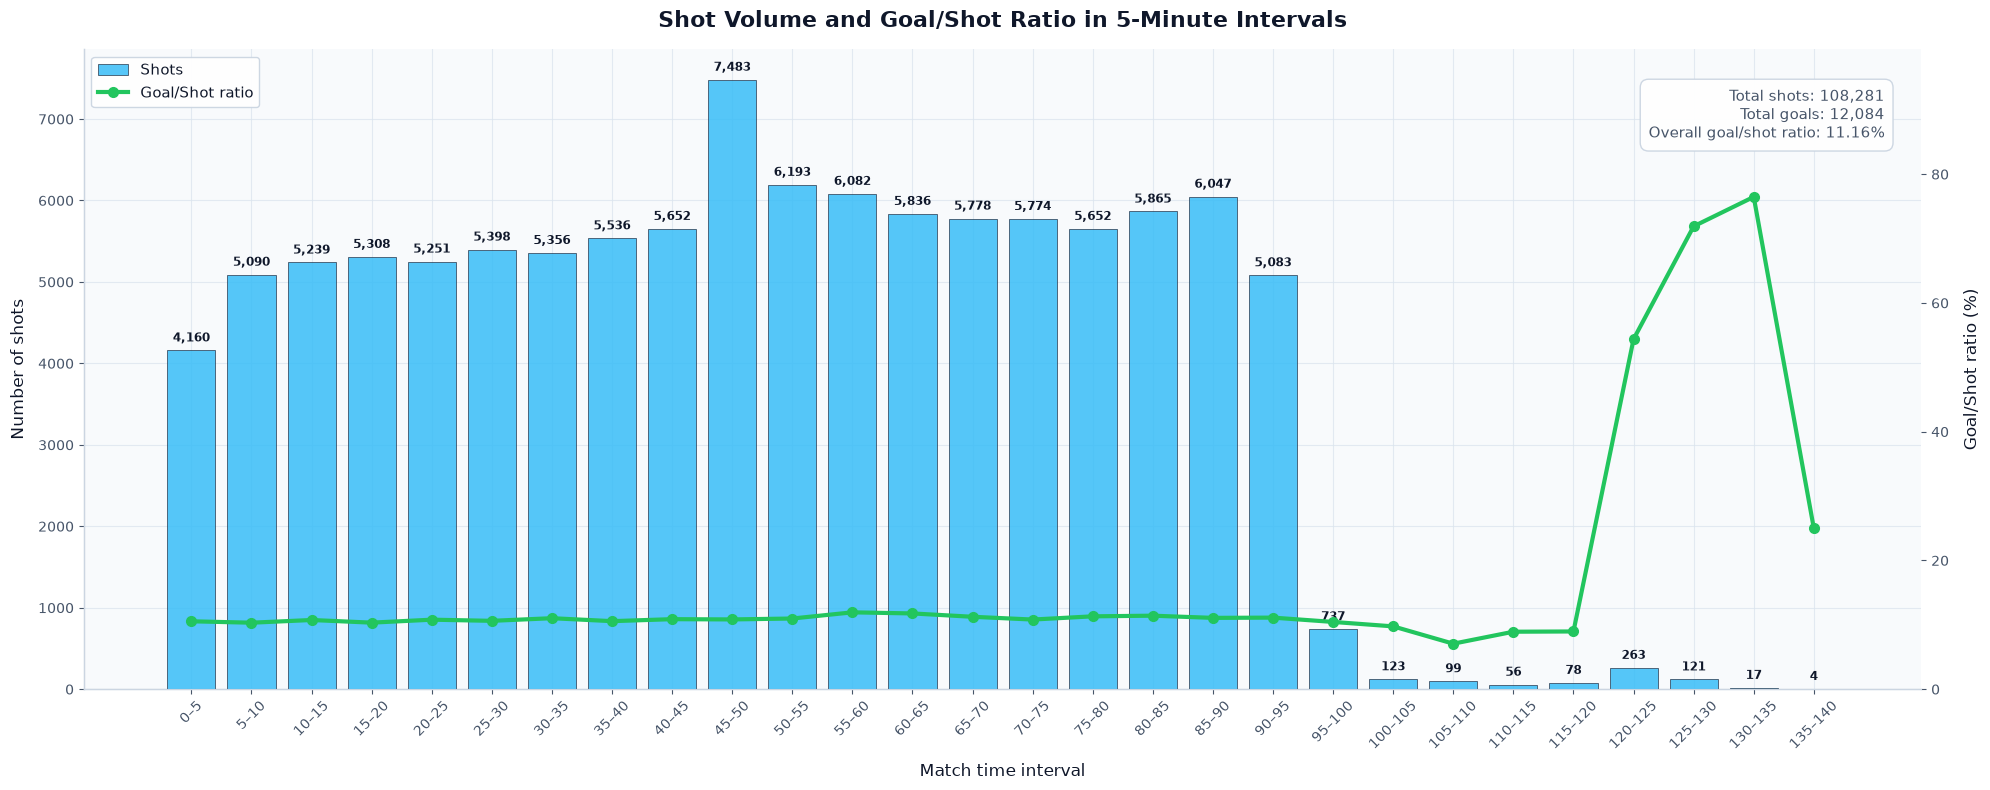

In [12]:
# Shot Volume and Goal Rate over Time
fig, ax1 = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor(BG)

bars = ax1.bar(
    shot_time_distribution["time_5min_interval"].astype(str),
    shot_time_distribution["shots"],
    color=BLUE,
    edgecolor="#0f172a",
    linewidth=0.5,
    alpha=0.85,
    zorder=3,
    label="Shots"
)

style_axis(
    ax1,
    title="Shot Volume and Goal/Shot Ratio in 5-Minute Intervals",
    xlabel="Match time interval",
    ylabel="Number of shots"
)

ax1.tick_params(axis="x", rotation=45)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + shot_time_distribution["shots"].max() * 0.01,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color=TEXT
    )

ax2 = ax1.twinx()

ax2.plot(
    shot_time_distribution["time_5min_interval"].astype(str),
    shot_time_distribution["goal_rate_percent"],
    color=GREEN,
    marker="o",
    markersize=7,
    linewidth=3,
    label="Goal/Shot ratio",
    zorder=5
)

ax2.set_ylabel("Goal/Shot ratio (%)", fontsize=12, color=TEXT, labelpad=10)
ax2.tick_params(axis="y", colors=SUBTEXT)
ax2.spines["right"].set_color(BORDER)
ax2.spines["top"].set_visible(False)

if shot_time_distribution["goal_rate_percent"].max() > 0:
    ax2.set_ylim(0, shot_time_distribution["goal_rate_percent"].max() * 1.30)

ax1.text(
    0.98,
    0.94,
    f"Total shots: {len(eda_basic_df):,}\n"
    f"Total goals: {int(eda_basic_df['goal'].sum()):,}\n"
    f"Overall goal/shot ratio: {eda_basic_df['goal'].mean():.2%}",
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    color=SUBTEXT,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=BORDER,
        alpha=0.96
    )
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=True,
    fontsize=11
)

plt.tight_layout()
save_fig("figures/shot_volume_and_goal_shot_ratio_5min.png")
plt.show()


## Pitch-Section Heat Maps

The pitch is divided into rectangular sections.

Two heat maps are created:

1. goal location heat map;
2. shot location heat map.

The green intensity scale is enhanced with nonlinear normalization so low-count areas are visible.

Saved figure: figures/goal_location_section_green_heatmap.png


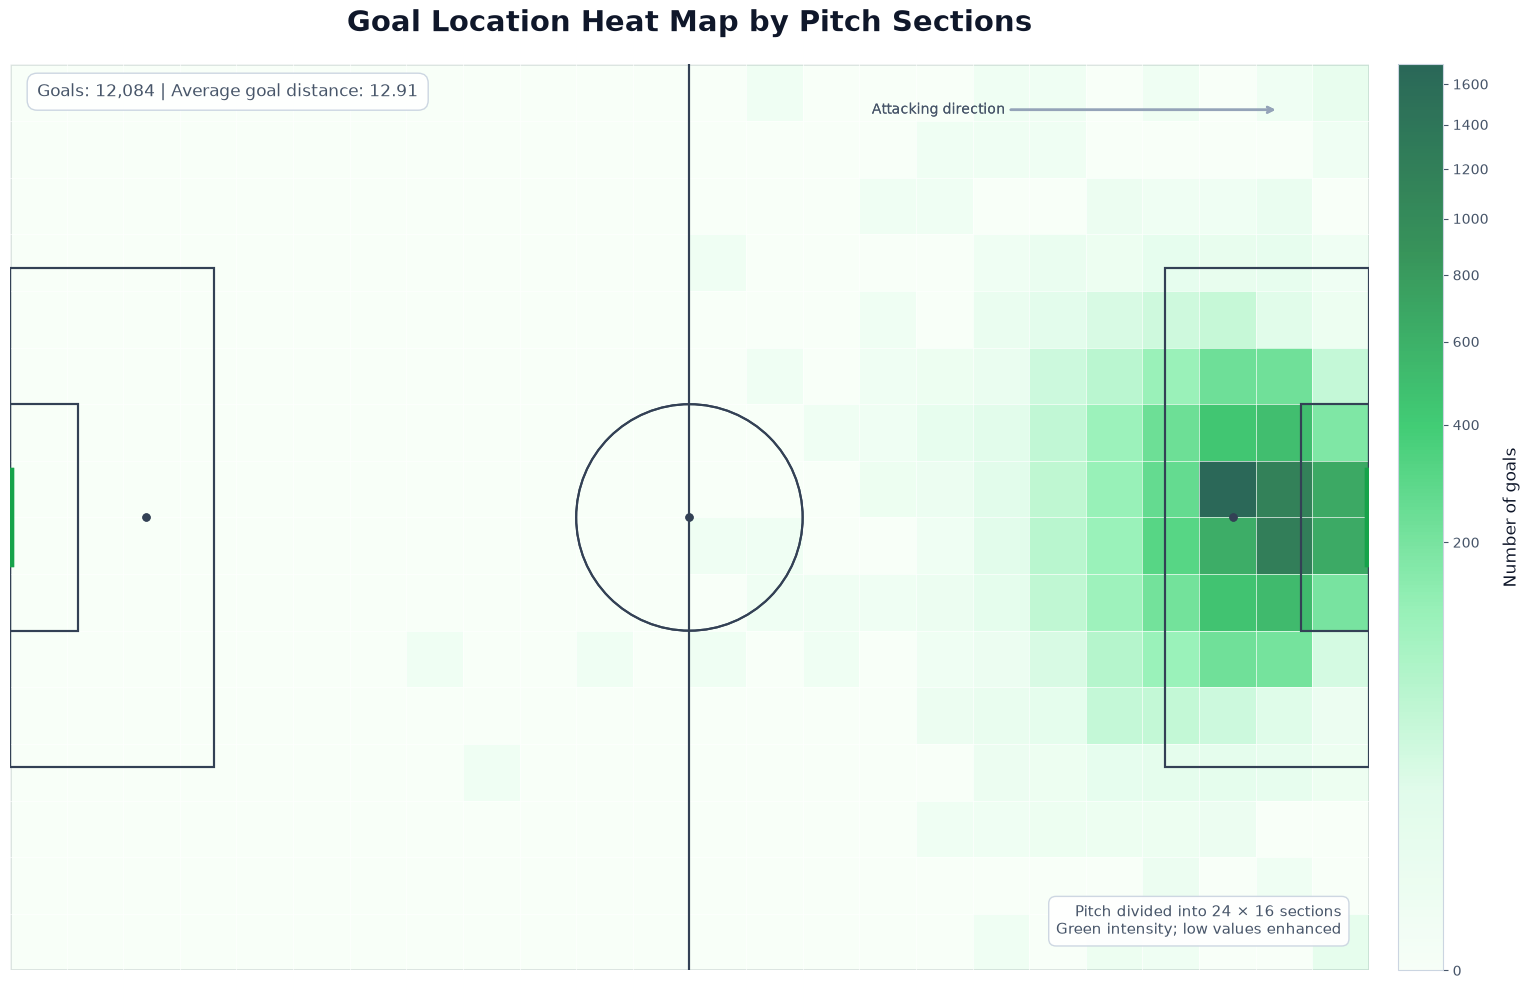

Saved figure: figures/shot_location_section_green_heatmap.png


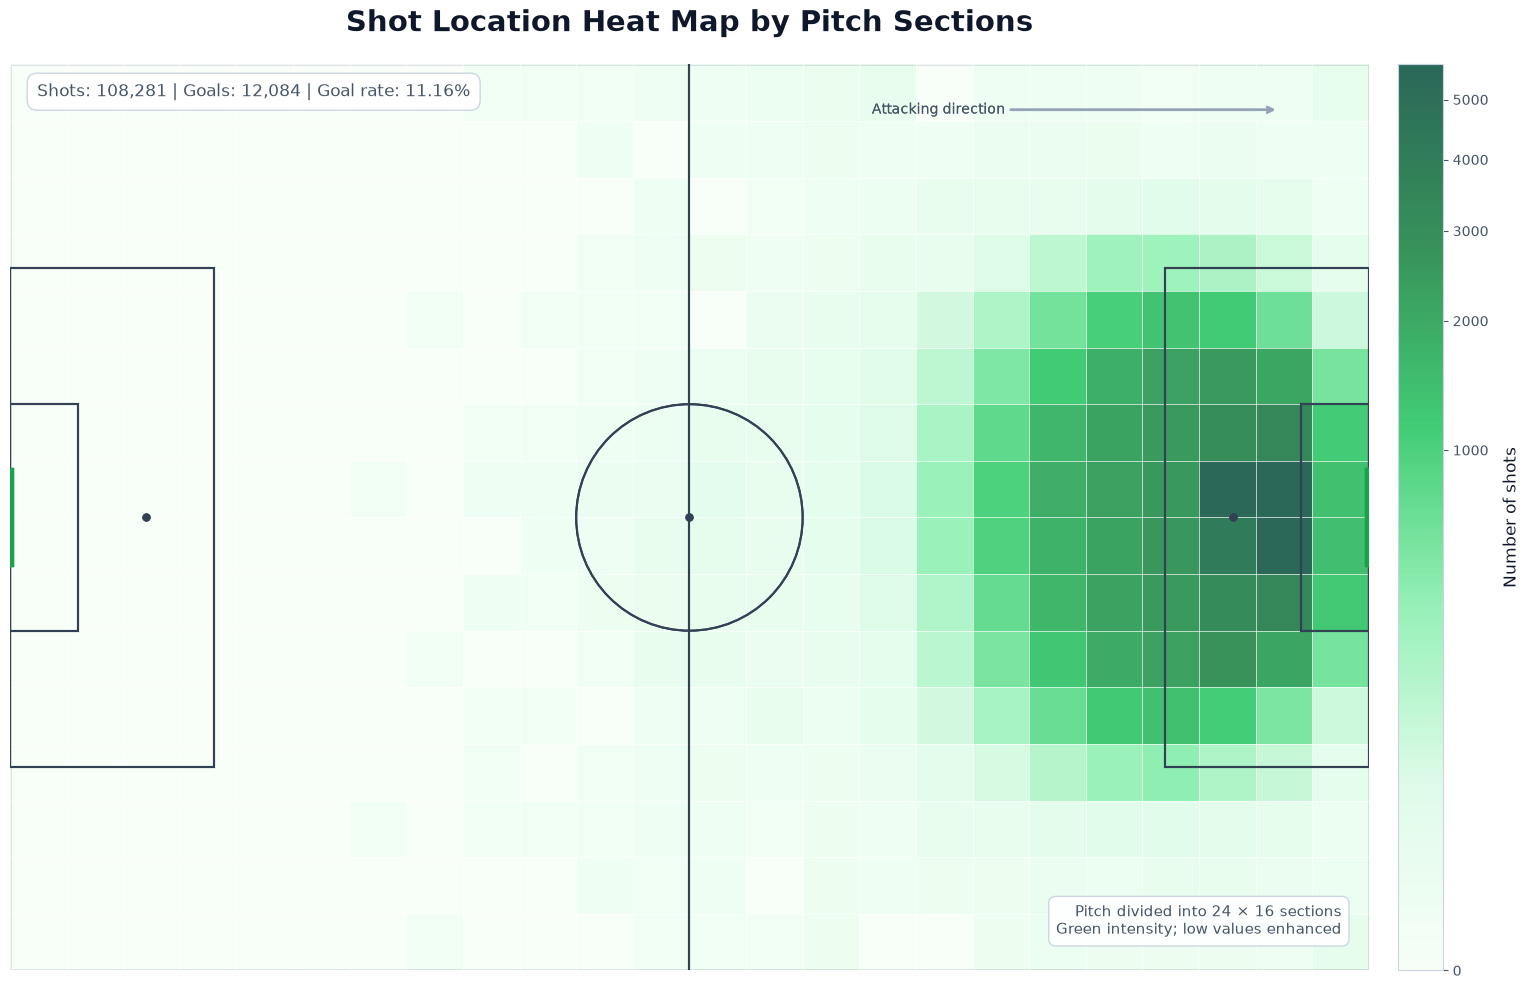

In [13]:
# Pitch-Section Heat Maps
def draw_beautiful_pitch(ax):
    pitch_bg = "#ffffff"
    line_color = "#334155"
    soft_line = "#94a3b8"

    ax.set_facecolor(pitch_bg)

    ax.add_patch(
        patches.Rectangle(
            (0, 0), 120, 80,
            linewidth=2.0,
            edgecolor=line_color,
            facecolor=pitch_bg,
            zorder=1
        )
    )

    ax.plot([60, 60], [0, 80], color=line_color, linewidth=1.5, zorder=7)

    ax.add_patch(patches.Circle((60, 40), 10, fill=False, edgecolor=line_color, linewidth=1.5, zorder=7))
    ax.scatter(60, 40, s=25, color=line_color, zorder=8)

    ax.add_patch(patches.Rectangle((102, 18), 18, 44, fill=False, edgecolor=line_color, linewidth=1.5, zorder=7))
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, fill=False, edgecolor=line_color, linewidth=1.5, zorder=7))

    ax.add_patch(patches.Rectangle((114, 30), 6, 20, fill=False, edgecolor=line_color, linewidth=1.5, zorder=7))
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, fill=False, edgecolor=line_color, linewidth=1.5, zorder=7))

    ax.scatter([108, 12], [40, 40], s=25, color=line_color, zorder=8)

    ax.plot([120, 120], [36, 44], color="#16a34a", linewidth=6, zorder=9)
    ax.plot([0, 0], [36, 44], color="#16a34a", linewidth=6, zorder=9)

    ax.annotate(
        "Attacking direction",
        xy=(112, 76),
        xytext=(82, 76),
        arrowprops=dict(arrowstyle="->", color=soft_line, linewidth=1.8),
        fontsize=10,
        color=SUBTEXT,
        ha="center",
        va="center",
        zorder=10
    )

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_aspect("equal")
    ax.axis("off")

    return ax

def plot_section_pitch_heatmap(
    data,
    title,
    subtitle,
    filename,
    value_label="Count",
    x_sections=24,
    y_sections=16,
    gamma=0.35
):
    x_edges = np.linspace(0, 120, x_sections + 1)
    y_edges = np.linspace(0, 80, y_sections + 1)

    counts, _, _ = np.histogram2d(
        data["x"],
        data["y"],
        bins=[x_edges, y_edges]
    )

    counts = counts.T
    max_count = np.nanmax(counts)

    norm = PowerNorm(
        gamma=gamma,
        vmin=0,
        vmax=max_count if max_count > 0 else 1
    )

    fig, ax = plt.subplots(figsize=(17, 10))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor("#ffffff")

    draw_beautiful_pitch(ax)

    heat = ax.pcolormesh(
        x_edges,
        y_edges,
        counts,
        cmap=PITCH_GREEN_CMAP,
        norm=norm,
        shading="flat",
        alpha=0.85,
        zorder=4
    )

    # Section grid
    for x_edge in x_edges:
        ax.plot([x_edge, x_edge], [0, 80], color="#ffffff", linewidth=0.55, alpha=0.85, zorder=6)
    for y_edge in y_edges:
        ax.plot([0, 120], [y_edge, y_edge], color="#ffffff", linewidth=0.55, alpha=0.85, zorder=6)

    # Pitch lines on top
    draw_beautiful_pitch(ax)

    cbar = plt.colorbar(heat, ax=ax, fraction=0.034, pad=0.018)
    cbar.set_label(value_label, color=TEXT, fontsize=12, labelpad=10)
    cbar.ax.tick_params(colors=SUBTEXT, labelsize=10)
    cbar.outline.set_edgecolor(BORDER)

    ax.set_title(title, fontsize=21, fontweight="bold", color=TEXT, pad=24)

    ax.text(
        0.02,
        0.965,
        subtitle,
        transform=ax.transAxes,
        fontsize=12,
        color=SUBTEXT,
        bbox=dict(
            boxstyle="round,pad=0.60",
            facecolor="white",
            edgecolor=BORDER,
            alpha=0.97
        ),
        zorder=20
    )

    ax.text(
        0.98,
        0.035,
        f"Pitch divided into {x_sections} × {y_sections} sections\nGreen intensity; low values enhanced",
        transform=ax.transAxes,
        fontsize=10.5,
        color=SUBTEXT,
        ha="right",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.50",
            facecolor="white",
            edgecolor=BORDER,
            alpha=0.94
        ),
        zorder=20
    )

    plt.tight_layout()
    save_fig(filename)
    plt.show()

    return counts

goals_df = shots_clean_df[shots_clean_df["goal"] == 1].copy()

goal_counts_grid = plot_section_pitch_heatmap(
    data=goals_df,
    title="Goal Location Heat Map by Pitch Sections",
    subtitle=(
        f"Goals: {len(goals_df):,} | "
        f"Average goal distance: {goals_df['distance_to_goal'].mean():.2f}"
    ),
    filename="figures/goal_location_section_green_heatmap.png",
    value_label="Number of goals",
    x_sections=24,
    y_sections=16,
    gamma=0.35
)

shot_counts_grid = plot_section_pitch_heatmap(
    data=shots_clean_df,
    title="Shot Location Heat Map by Pitch Sections",
    subtitle=(
        f"Shots: {len(shots_clean_df):,} | "
        f"Goals: {int(shots_clean_df['goal'].sum()):,} | "
        f"Goal rate: {shots_clean_df['goal'].mean():.2%}"
    ),
    filename="figures/shot_location_section_green_heatmap.png",
    value_label="Number of shots",
    x_sections=24,
    y_sections=16,
    gamma=0.32
)


## Goal-Rate EDA Dashboard

These dashboards compare the empirical goal rate against important features.

Only the real target variable `goal` is used here. StatsBomb xG is not used.

Saved figure: figures/goal_rate_dashboard_1_core_features.png


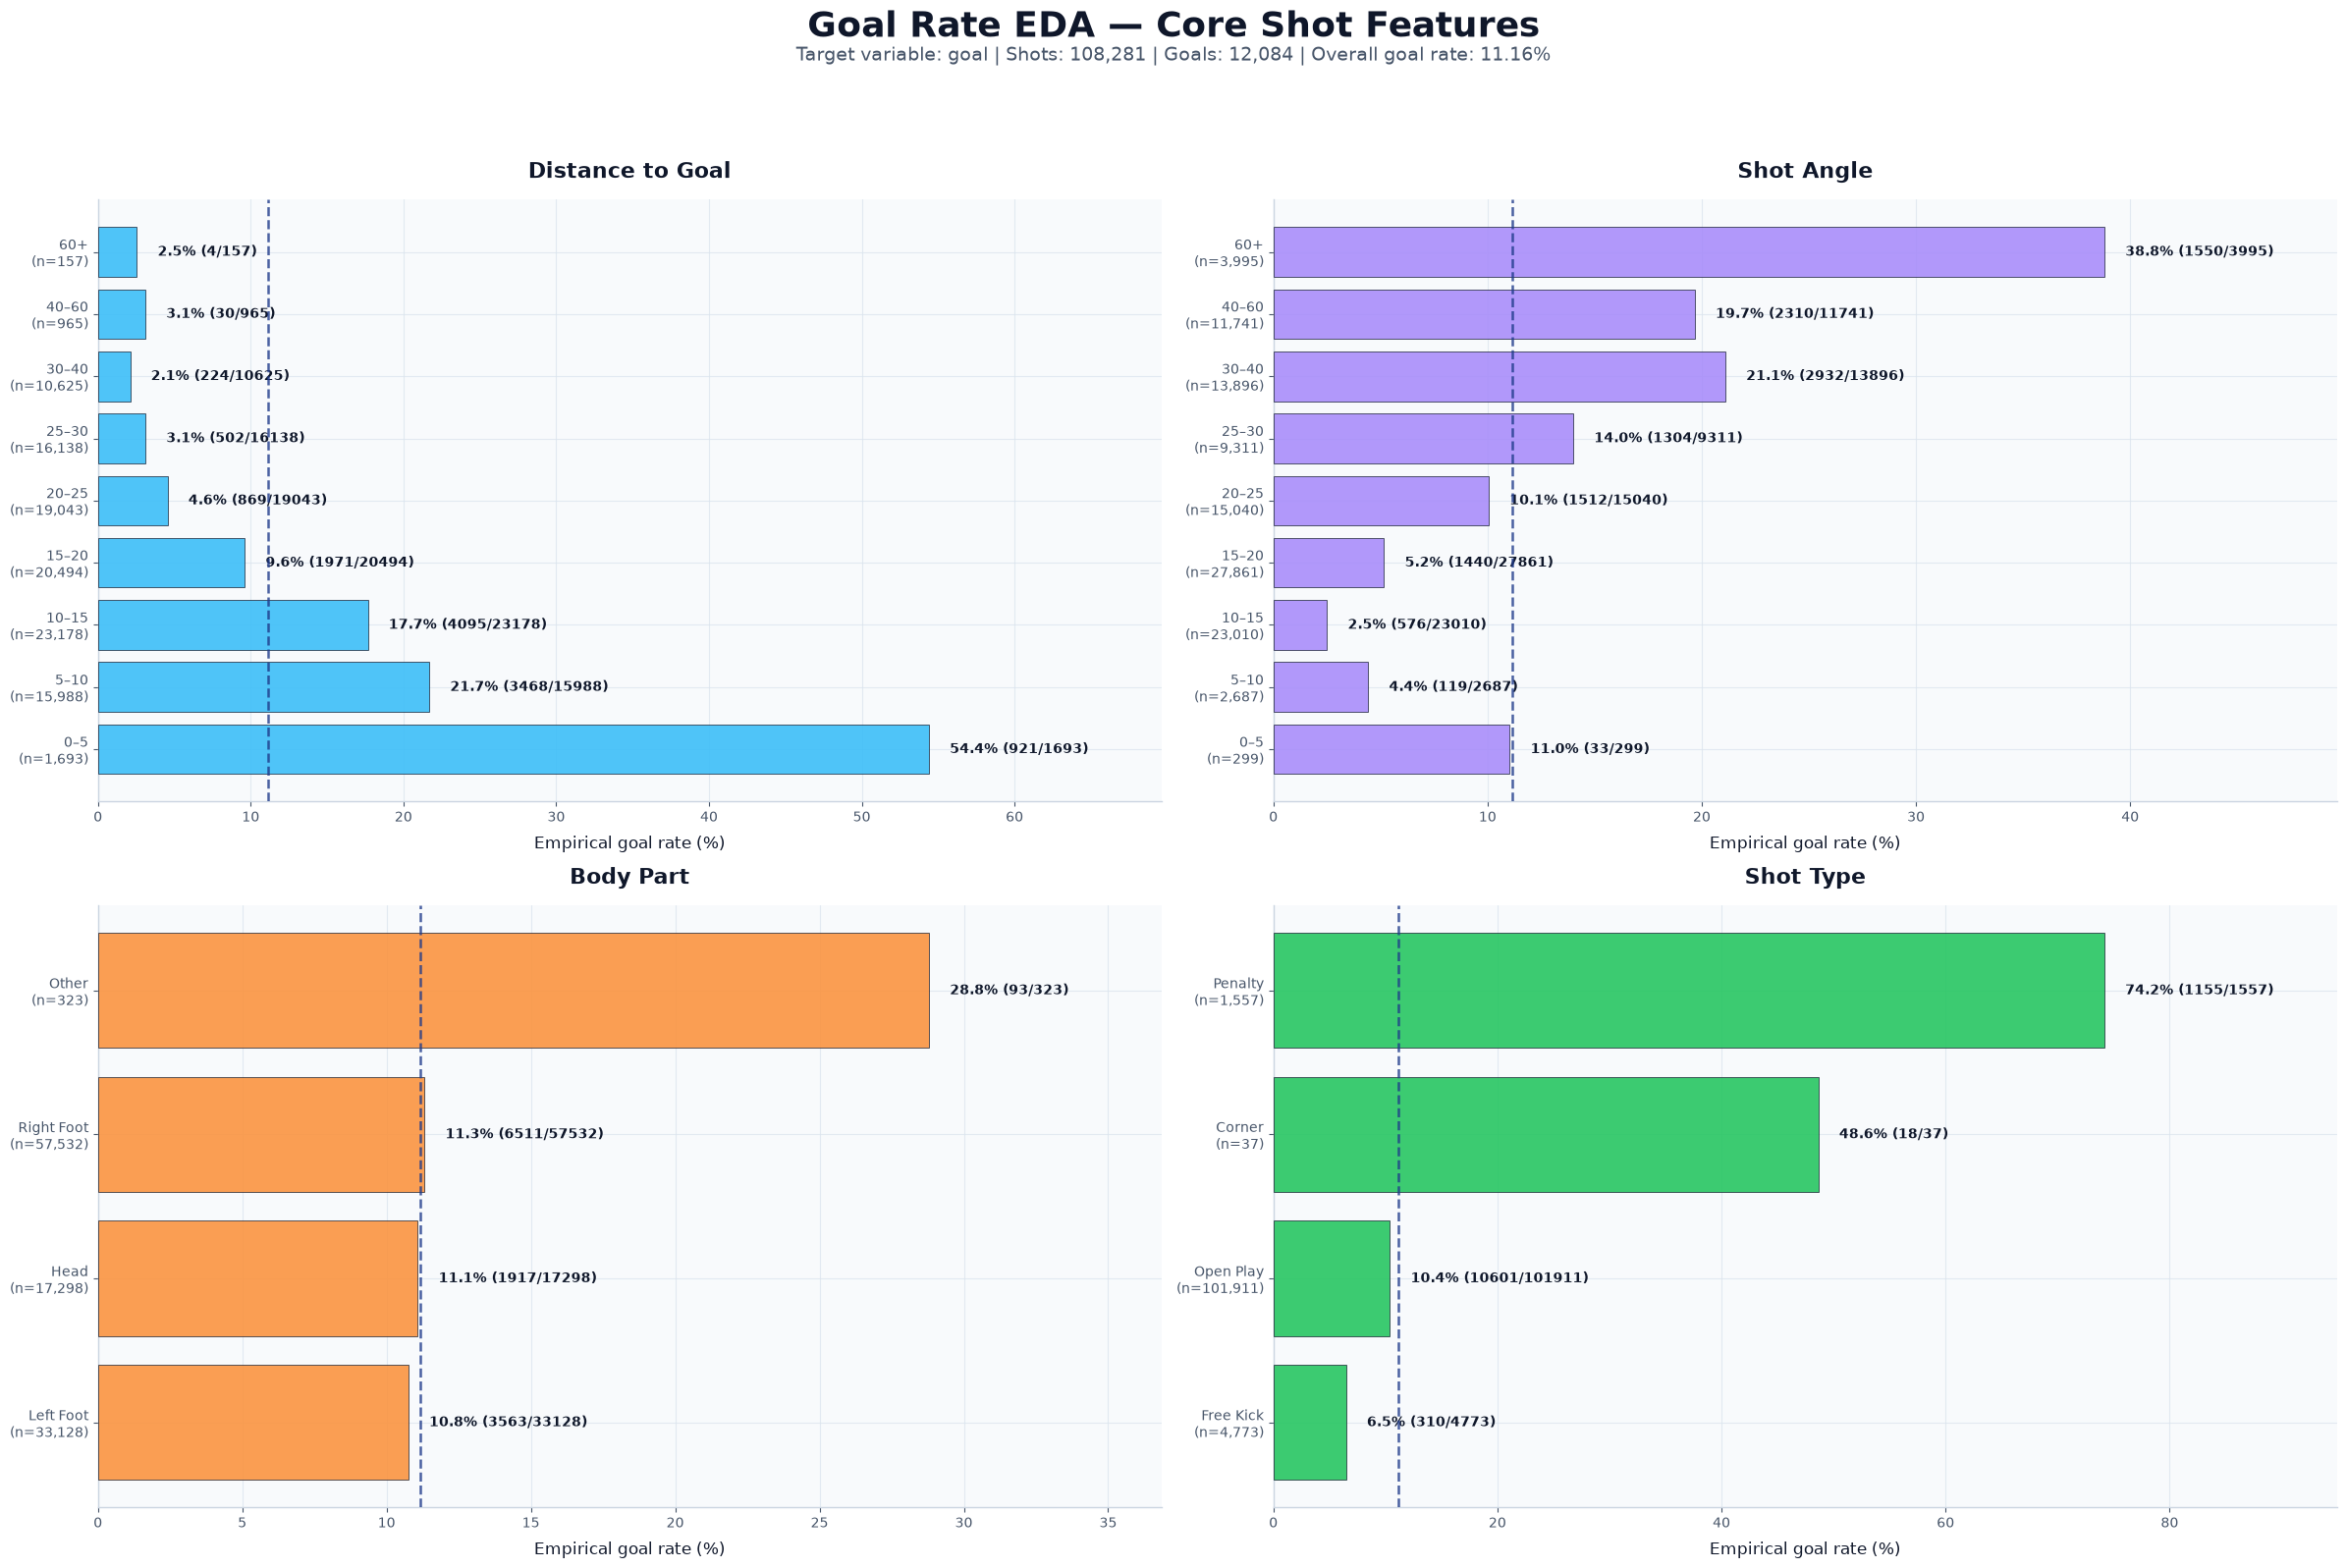

Saved figure: figures/goal_rate_dashboard_2_context_features.png


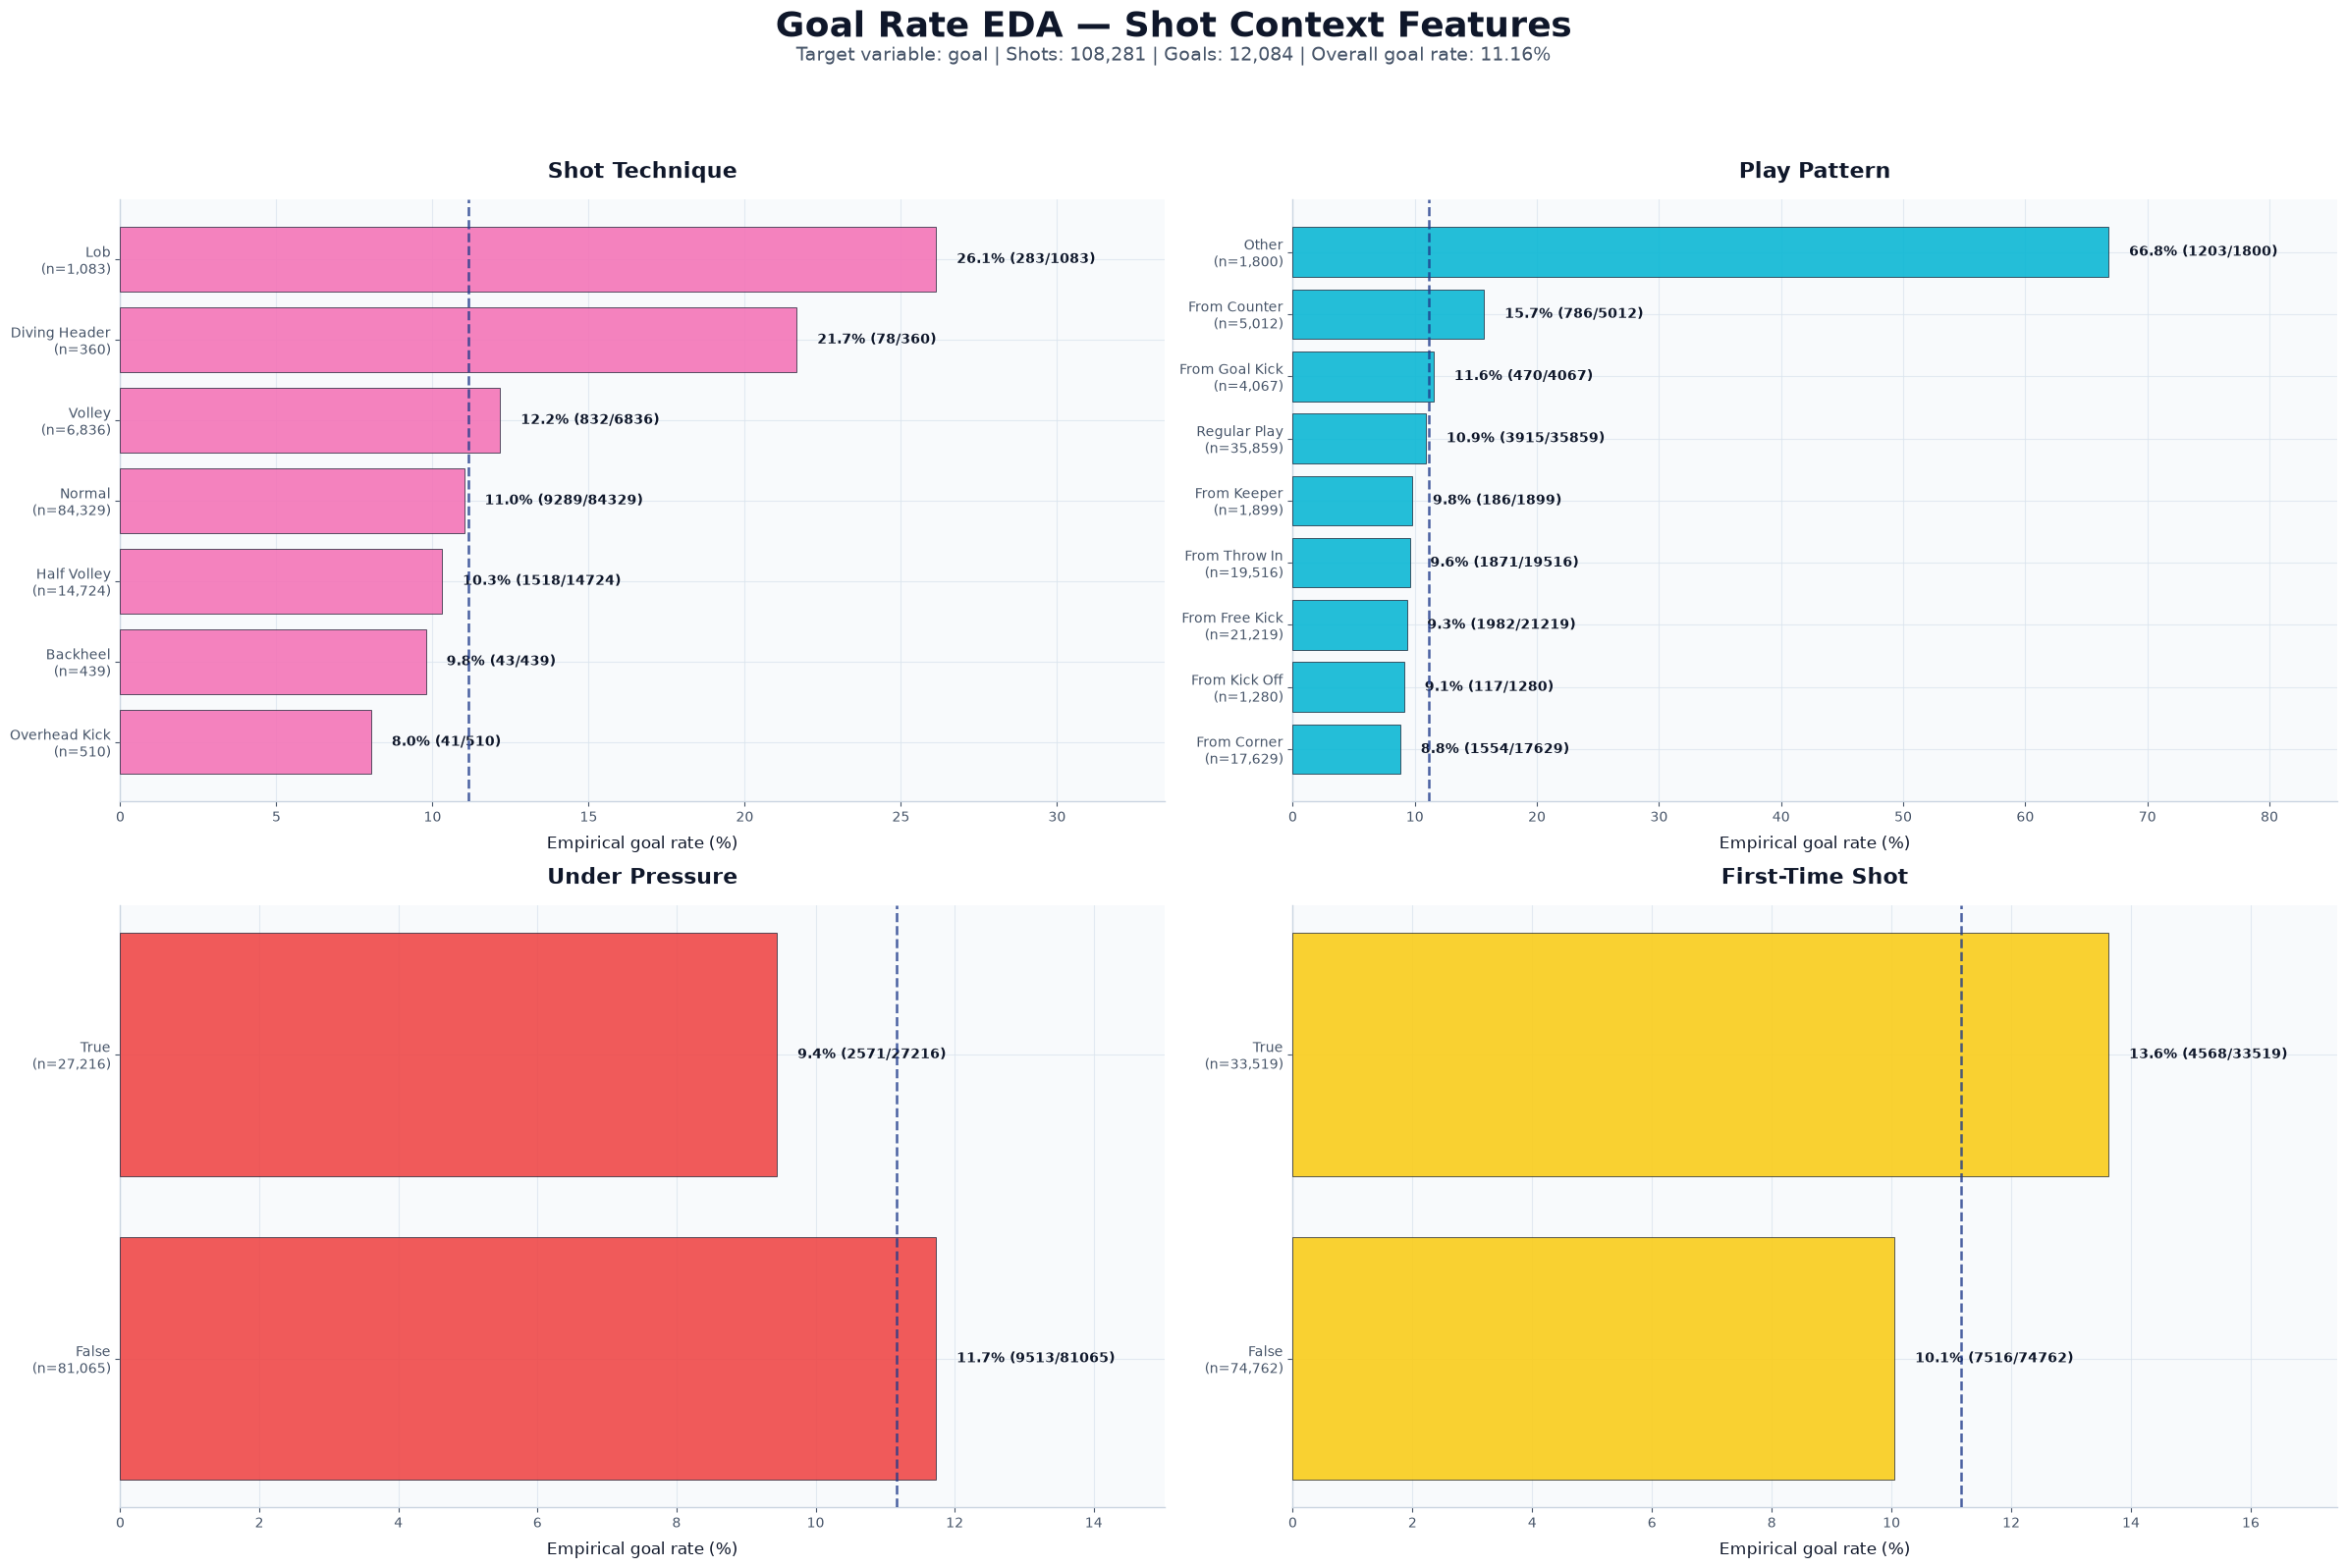

Saved figure: figures/goal_rate_dashboard_3_goalkeeper_pressure_features.png


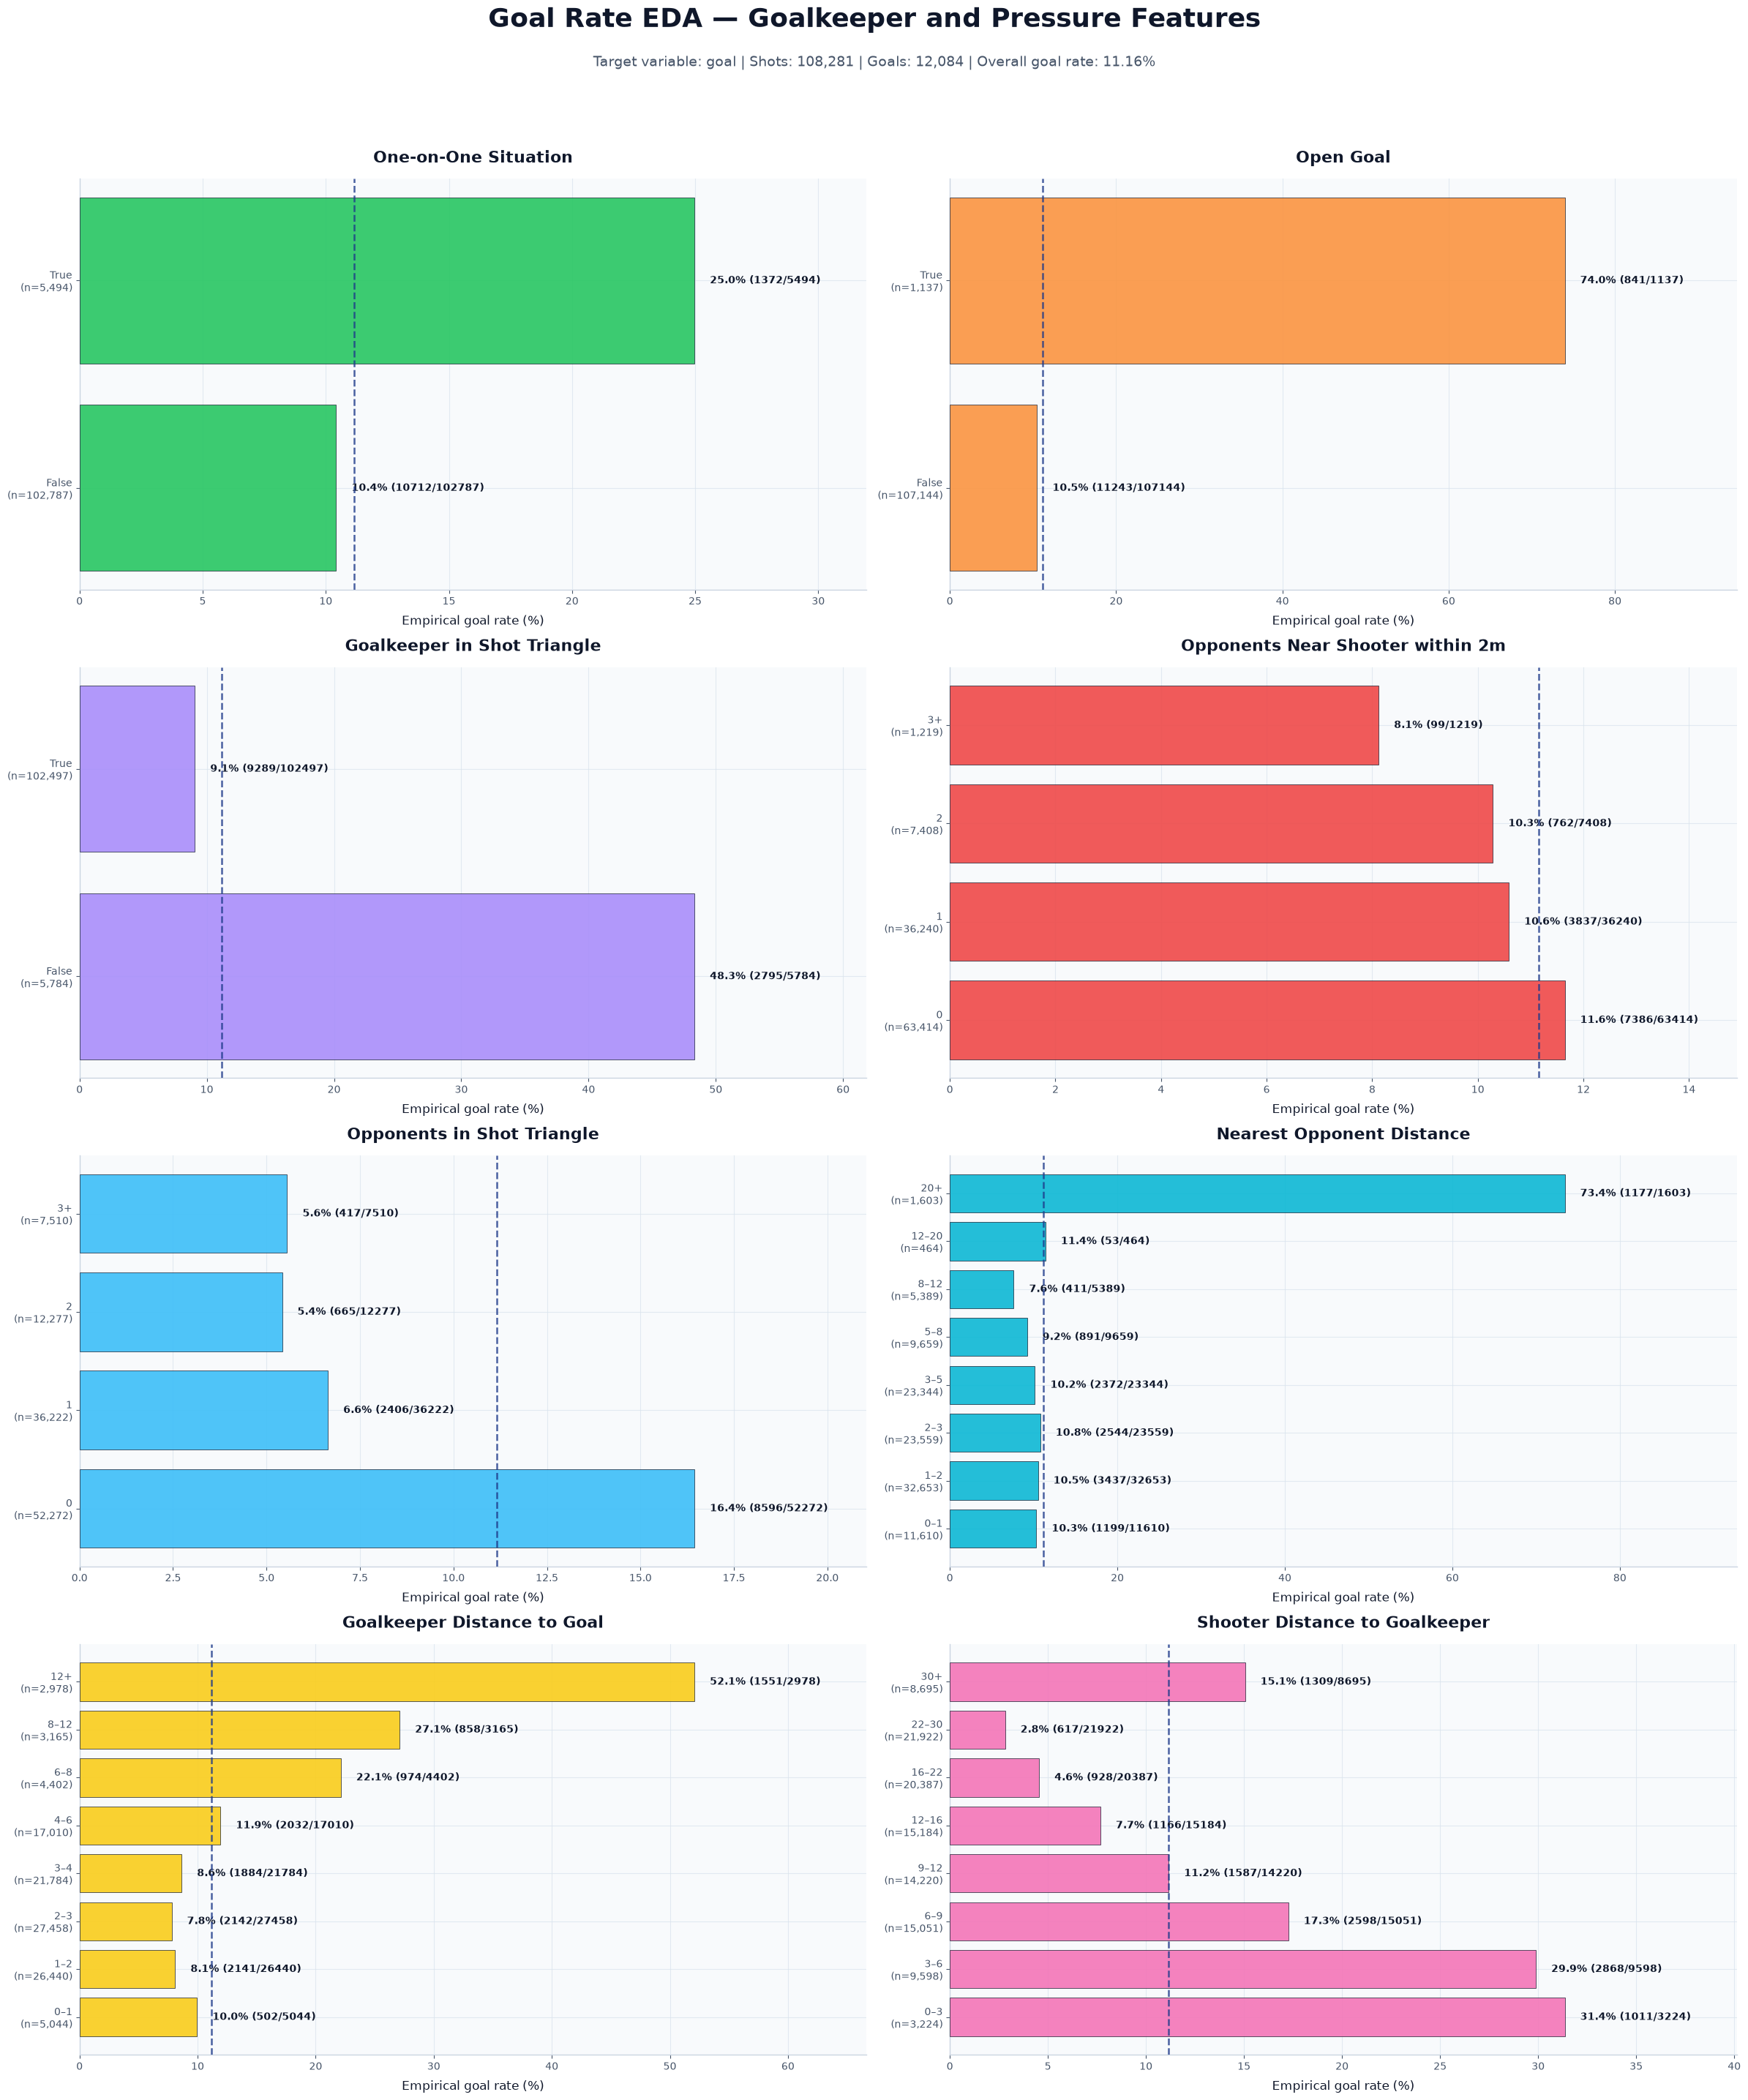

Saved figure: figures/goal_rate_dashboard_4_position.png


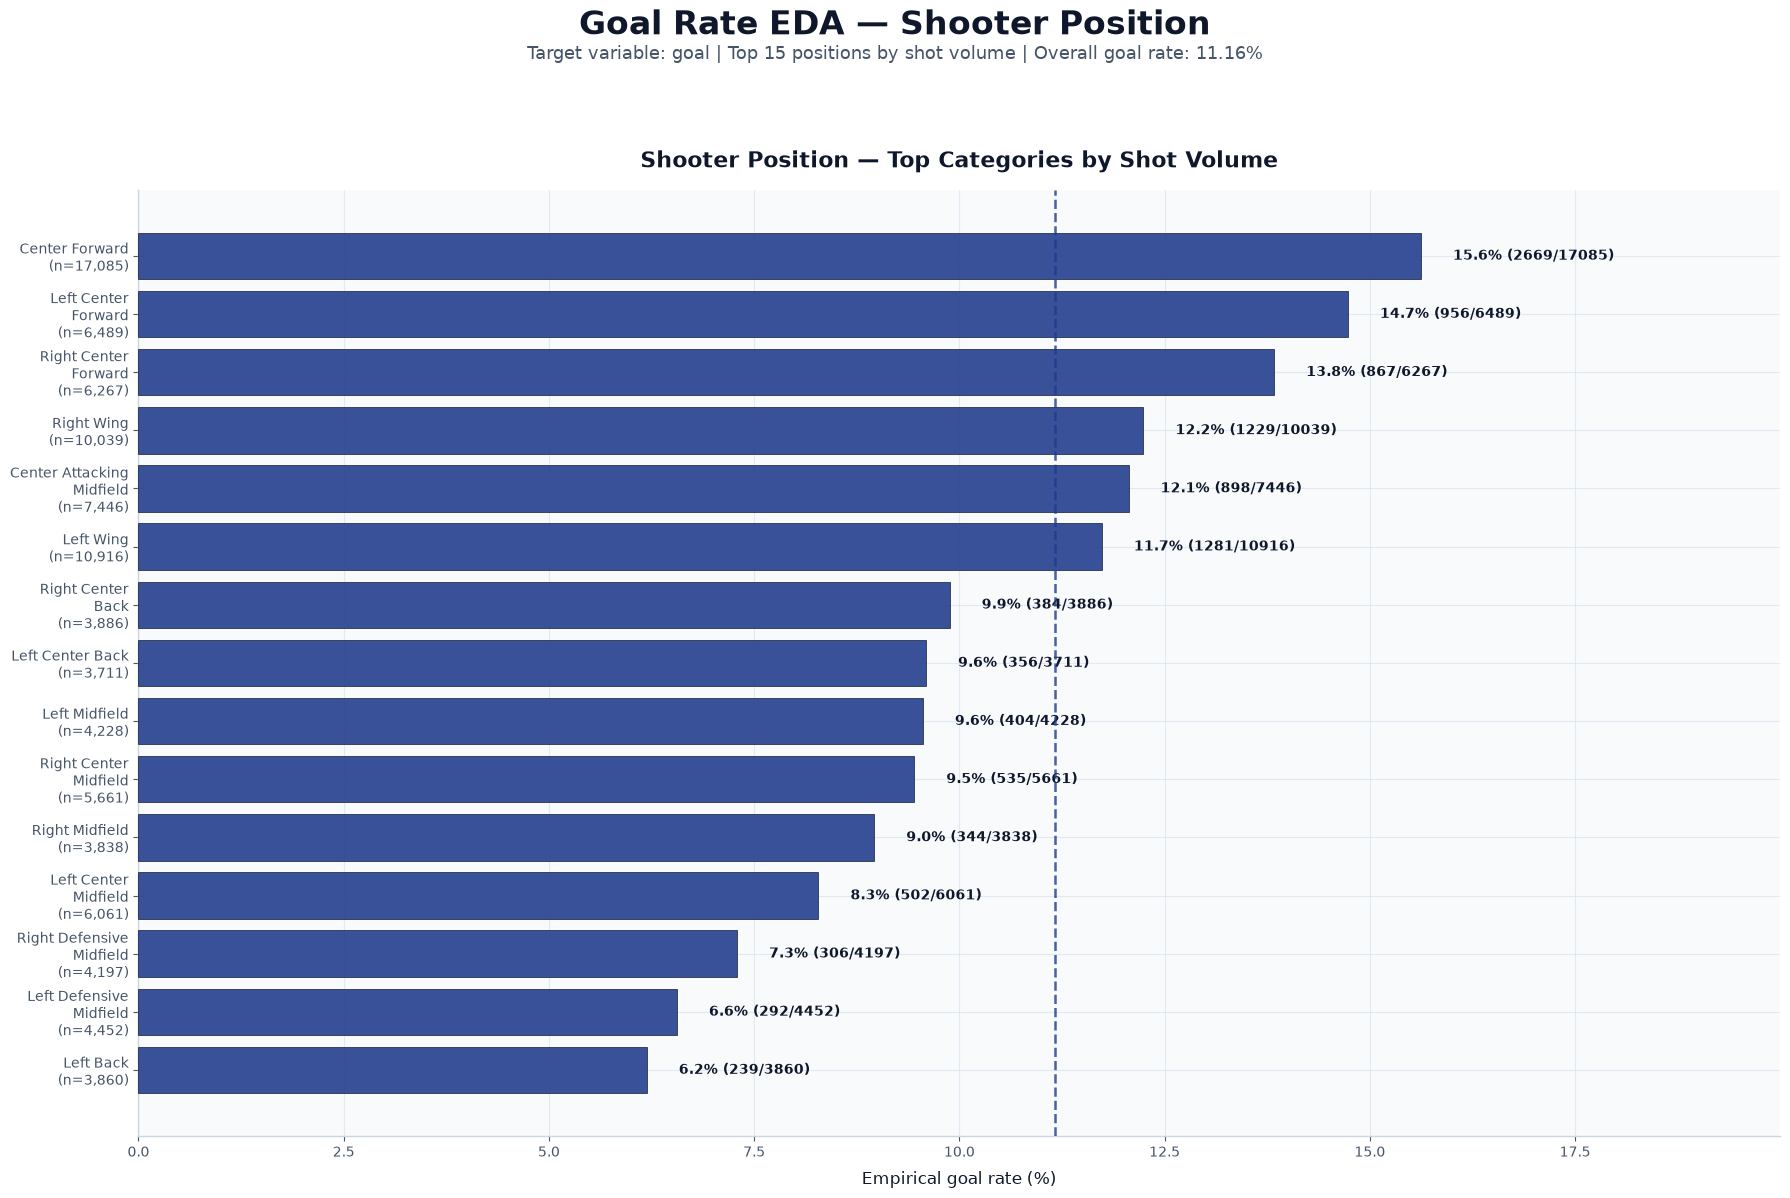

In [14]:
# Goal-Rate EDA Dashboard
# ============================================================
# Large goal-rate EDA dashboards
# Target variable: goal only
# ============================================================

from math import ceil

def shorten_label(label, width=18):
    label = str(label)
    return "\n".join(textwrap.wrap(label, width=width))

def make_goal_rate_summary(data, feature, min_count=20):
    summary = (
        data
        .groupby(feature, observed=True)
        .agg(
            shots=("goal", "count"),
            goals=("goal", "sum"),
            goal_rate=("goal", "mean")
        )
        .reset_index()
    )

    summary = summary[summary["shots"] >= min_count].copy()
    summary["goal_rate_percent"] = summary["goal_rate"] * 100

    return summary

def plot_goal_rate_bar(
    ax,
    data,
    feature,
    title,
    color,
    min_count=20,
    top_n=None,
    sort_by="category",
    ordered_categories=None
):
    summary = make_goal_rate_summary(data, feature, min_count=min_count)

    if len(summary) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=14, color=SUBTEXT)
        ax.set_axis_off()
        return None

    if ordered_categories is not None:
        summary[feature] = pd.Categorical(summary[feature], categories=ordered_categories, ordered=True)
        summary = summary.sort_values(feature)
    elif sort_by == "goal_rate":
        summary = summary.sort_values("goal_rate_percent", ascending=True)
    elif sort_by == "shots":
        summary = summary.sort_values("shots", ascending=True)
    else:
        summary = summary.sort_values(feature, ascending=True)

    if top_n is not None and len(summary) > top_n:
        summary = summary.sort_values("shots", ascending=False).head(top_n)
        summary = summary.sort_values("goal_rate_percent", ascending=True)

    labels = [
        f"{shorten_label(v, width=16)}\n(n={int(n):,})"
        for v, n in zip(summary[feature], summary["shots"])
    ]

    bars = ax.barh(
        labels,
        summary["goal_rate_percent"],
        color=color,
        edgecolor="#0f172a",
        linewidth=0.55,
        alpha=0.88,
        zorder=3
    )

    style_axis(ax, title=title, xlabel="Empirical goal rate (%)", ylabel=None)

    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)

    max_value = summary["goal_rate_percent"].max()
    ax.set_xlim(0, max_value * 1.28 if max_value > 0 else 1)

    for bar, rate, goals, shots in zip(bars, summary["goal_rate_percent"], summary["goals"], summary["shots"]):
        width = bar.get_width()
        ax.text(
            width + max_value * 0.025,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}% ({int(goals)}/{int(shots)})",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color=TEXT
        )

    ax.axvline(
        data["goal"].mean() * 100,
        color=NAVY,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        zorder=4
    )

    return summary

def add_dashboard_title(fig, title, data):
    fig.suptitle(title, fontsize=26, fontweight="bold", color=TEXT, y=0.995)
    fig.text(
        0.5,
        0.972,
        f"Target variable: goal | Shots: {len(data):,} | Goals: {int(data['goal'].sum()):,} | Overall goal rate: {data['goal'].mean():.2%}",
        ha="center",
        va="top",
        fontsize=14,
        color=SUBTEXT
    )

eda_df = shots_clean_df.copy()

distance_labels = ["0–5", "5–10", "10–15", "15–20", "20–25", "25–30", "30–40", "40–60", "60+"]
eda_df["distance_bin"] = pd.cut(
    eda_df["distance_to_goal"],
    bins=[0, 5, 10, 15, 20, 25, 30, 40, 60, 100],
    labels=distance_labels,
    include_lowest=True,
    right=False
)

angle_labels = ["0–5", "5–10", "10–15", "15–20", "20–25", "25–30", "30–40", "40–60", "60+"]
eda_df["angle_bin"] = pd.cut(
    eda_df["shot_angle"],
    bins=[0, 5, 10, 15, 20, 25, 30, 40, 60, 100],
    labels=angle_labels,
    include_lowest=True,
    right=False
)

if "gk_distance_to_goal" in eda_df.columns:
    gk_goal_labels = ["0–1", "1–2", "2–3", "3–4", "4–6", "6–8", "8–12", "12+"]
    eda_df["gk_distance_to_goal_bin"] = pd.cut(
        eda_df["gk_distance_to_goal"],
        bins=[0, 1, 2, 3, 4, 6, 8, 12, 1000],
        labels=gk_goal_labels,
        include_lowest=True,
        right=False
    )

if "distance_to_gk" in eda_df.columns:
    distance_to_gk_labels = ["0–3", "3–6", "6–9", "9–12", "12–16", "16–22", "22–30", "30+"]
    eda_df["distance_to_gk_bin"] = pd.cut(
        eda_df["distance_to_gk"],
        bins=[0, 3, 6, 9, 12, 16, 22, 30, 1000],
        labels=distance_to_gk_labels,
        include_lowest=True,
        right=False
    )

if "nearest_opponent_distance" in eda_df.columns:
    nearest_opp_labels = ["0–1", "1–2", "2–3", "3–5", "5–8", "8–12", "12–20", "20+"]
    eda_df["nearest_opponent_distance_bin"] = pd.cut(
        eda_df["nearest_opponent_distance"],
        bins=[0, 1, 2, 3, 5, 8, 12, 20, 1000],
        labels=nearest_opp_labels,
        include_lowest=True,
        right=False
    )

def cap_count(value):
    if pd.isna(value):
        return "Unknown"
    value = int(value)
    if value >= 3:
        return "3+"
    return str(value)

for col in [
    "num_opponents_near_shooter_1m",
    "num_opponents_near_shooter_2m",
    "num_teammates_near_shooter_2m",
    "opponents_in_shot_triangle",
    "teammates_in_shot_triangle"
]:
    if col in eda_df.columns:
        eda_df[col + "_cat"] = eda_df[col].apply(cap_count)

# Dashboard page 1
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

plot_goal_rate_bar(axes[0], eda_df, "distance_bin", "Distance to Goal", color=BLUE, ordered_categories=distance_labels)
plot_goal_rate_bar(axes[1], eda_df, "angle_bin", "Shot Angle", color=PURPLE, ordered_categories=angle_labels)
plot_goal_rate_bar(axes[2], eda_df, "body_part", "Body Part", color=ORANGE, sort_by="goal_rate")
plot_goal_rate_bar(axes[3], eda_df, "shot_type", "Shot Type", color=GREEN, sort_by="goal_rate")

add_dashboard_title(fig, "Goal Rate EDA — Core Shot Features", eda_df)
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_fig("figures/goal_rate_dashboard_1_core_features.png")
plt.show()

# Dashboard page 2
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

plot_goal_rate_bar(axes[0], eda_df, "technique", "Shot Technique", color=PINK, sort_by="goal_rate", top_n=12)
plot_goal_rate_bar(axes[1], eda_df, "play_pattern", "Play Pattern", color=CYAN, sort_by="goal_rate", top_n=10)
plot_goal_rate_bar(axes[2], eda_df, "under_pressure", "Under Pressure", color=RED, sort_by="category")
plot_goal_rate_bar(axes[3], eda_df, "first_time", "First-Time Shot", color=GOLD, sort_by="category")

add_dashboard_title(fig, "Goal Rate EDA — Shot Context Features", eda_df)
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_fig("figures/goal_rate_dashboard_2_context_features.png")
plt.show()

# Dashboard page 3
page3_features = [
    ("one_on_one", "One-on-One Situation", GREEN, "category", None, None),
    ("open_goal", "Open Goal", ORANGE, "category", None, None),
    ("gk_in_shot_triangle", "Goalkeeper in Shot Triangle", PURPLE, "category", None, None),
    ("num_opponents_near_shooter_2m_cat", "Opponents Near Shooter within 2m", RED, "category", None, ["0", "1", "2", "3+"]),
    ("opponents_in_shot_triangle_cat", "Opponents in Shot Triangle", BLUE, "category", None, ["0", "1", "2", "3+"]),
    ("nearest_opponent_distance_bin", "Nearest Opponent Distance", CYAN, "category", None, nearest_opp_labels if "nearest_opp_labels" in globals() else None),
    ("gk_distance_to_goal_bin", "Goalkeeper Distance to Goal", GOLD, "category", None, gk_goal_labels if "gk_goal_labels" in globals() else None),
    ("distance_to_gk_bin", "Shooter Distance to Goalkeeper", PINK, "category", None, distance_to_gk_labels if "distance_to_gk_labels" in globals() else None),
]

page3_features = [item for item in page3_features if item[0] in eda_df.columns]

n_cols = 2
n_rows = int(np.ceil(len(page3_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 7.2 * n_rows))
fig.patch.set_facecolor(BG)
axes = np.array(axes).flatten()

for ax, (feature, title, color, sort_by, top_n, ordered_categories) in zip(axes, page3_features):
    plot_goal_rate_bar(
        ax,
        eda_df,
        feature,
        title,
        color=color,
        sort_by=sort_by,
        top_n=top_n,
        ordered_categories=ordered_categories
    )

for ax in axes[len(page3_features):]:
    ax.set_axis_off()

add_dashboard_title(fig, "Goal Rate EDA — Goalkeeper and Pressure Features", eda_df)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_fig("figures/goal_rate_dashboard_3_goalkeeper_pressure_features.png")
plt.show()

# Dashboard page 4 — position
if "position" in eda_df.columns:
    fig, ax = plt.subplots(figsize=(18, 12))
    fig.patch.set_facecolor(BG)

    plot_goal_rate_bar(
        ax,
        eda_df,
        "position",
        "Shooter Position — Top Categories by Shot Volume",
        color=NAVY,
        sort_by="goal_rate",
        top_n=15
    )

    fig.suptitle("Goal Rate EDA — Shooter Position", fontsize=24, fontweight="bold", color=TEXT, y=0.995)
    fig.text(
        0.5,
        0.965,
        f"Target variable: goal | Top 15 positions by shot volume | Overall goal rate: {eda_df['goal'].mean():.2%}",
        ha="center",
        va="top",
        fontsize=13,
        color=SUBTEXT
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    save_fig("figures/goal_rate_dashboard_4_position.png")
    plt.show()


## Modeling Dataset Preparation

From this point onward, the notebook moves from EDA to modeling.

This section creates:

- numerical features for Logistic Regression and Random Forest;
- categorical states for Bayesian Networks;
- intermediate variables for the expert Bayesian Network.

In [15]:
# Modeling Dataset Preparation
# ============================================================
# Prepare modeling dataset
# Target: is_goal
# ============================================================

model_df = shots_clean_df.copy()
model_df["is_goal"] = model_df["goal"].astype(int)

def safe_bool_to_yes_no(value):
    return "Yes" if bool(value) else "No"

def count_to_state(value):
    if pd.isna(value):
        return "Unknown"

    value = int(value)

    if value == 0:
        return "None"
    elif value == 1:
        return "One"
    elif value == 2:
        return "Two"
    else:
        return "ThreePlus"

def simplify_body_part(value):
    value = str(value)

    if value in ["Right Foot", "Left Foot"]:
        return "Foot"
    elif value == "Head":
        return "Head"
    else:
        return "Other"

def simplify_shot_type(value):
    value = str(value)

    if value == "Open Play":
        return "Open Play"
    elif value == "Penalty":
        return "Penalty"
    elif value == "Free Kick":
        return "Free Kick"
    else:
        return "Other"

def simplify_technique(value):
    value = str(value)

    if value in ["Normal", "Half Volley", "Volley"]:
        return value
    else:
        return "Other"

def simplify_play_pattern(value):
    value = str(value)

    if value in ["Regular Play", "From Corner", "From Free Kick", "From Throw In", "From Counter"]:
        return value
    else:
        return "Other"

# Discrete variables for Bayesian Network
model_df["Distance"] = pd.cut(
    model_df["distance_to_goal"],
    bins=[0, 8, 15, 25, 100],
    labels=["Very Close", "Close", "Medium", "Far"],
    include_lowest=True,
    right=False
)

model_df["Angle"] = pd.cut(
    model_df["shot_angle"],
    bins=[0, 10, 25, 45, 100],
    labels=["Very Narrow", "Narrow", "Medium", "Wide"],
    include_lowest=True,
    right=False
)

model_df["BodyPart"] = model_df["body_part"].apply(simplify_body_part)
model_df["ShotType"] = model_df["shot_type"].apply(simplify_shot_type)
model_df["Technique"] = model_df["technique"].apply(simplify_technique)
model_df["PlayPattern"] = model_df["play_pattern"].apply(simplify_play_pattern)

model_df["UnderPressure"] = model_df["under_pressure"].apply(safe_bool_to_yes_no)
model_df["FirstTime"] = model_df["first_time"].apply(safe_bool_to_yes_no)
model_df["OneOnOne"] = model_df["one_on_one"].apply(safe_bool_to_yes_no)
model_df["OpenGoal"] = model_df["open_goal"].apply(safe_bool_to_yes_no)
model_df["GKInTriangle"] = model_df["gk_in_shot_triangle"].apply(safe_bool_to_yes_no)

model_df["OpponentsNearShooter"] = model_df["num_opponents_near_shooter_2m"].apply(count_to_state)
model_df["OpponentsInTriangle"] = model_df["opponents_in_shot_triangle"].apply(count_to_state)

model_df["NearestOpponent"] = pd.cut(
    model_df["nearest_opponent_distance"],
    bins=[0, 2, 5, 10, 1000],
    labels=["Very Close", "Close", "Medium", "Far"],
    include_lowest=True,
    right=False
)

model_df["GKDistanceToGoal"] = pd.cut(
    model_df["gk_distance_to_goal"],
    bins=[0, 2, 5, 10, 1000],
    labels=["On Line", "Close", "Advanced", "Far"],
    include_lowest=True,
    right=False
)

# Intermediate BN variables
def create_geometry_quality(row):
    distance = str(row["Distance"])
    angle = str(row["Angle"])

    if distance in ["Very Close", "Close"] and angle in ["Medium", "Wide"]:
        return "High"
    elif distance == "Far" or angle == "Very Narrow":
        return "Low"
    else:
        return "Medium"

def create_shot_execution(row):
    body = str(row["BodyPart"])
    technique = str(row["Technique"])
    first_time = str(row["FirstTime"])

    if body == "Foot" and technique == "Normal" and first_time == "No":
        return "Stable"
    elif technique in ["Volley", "Half Volley"] or first_time == "Yes":
        return "Difficult"
    else:
        return "Medium"

def create_defensive_pressure(row):
    under_pressure = str(row["UnderPressure"])
    opponents_near = str(row["OpponentsNearShooter"])
    opponents_triangle = str(row["OpponentsInTriangle"])

    if under_pressure == "Yes" or opponents_near in ["Two", "ThreePlus"] or opponents_triangle in ["Two", "ThreePlus"]:
        return "High"
    elif opponents_near == "One" or opponents_triangle == "One":
        return "Medium"
    else:
        return "Low"

def create_goalkeeper_context(row):
    gk_triangle = str(row["GKInTriangle"])
    gk_distance = str(row["GKDistanceToGoal"])

    if gk_triangle == "Yes" and gk_distance in ["On Line", "Close"]:
        return "Strong"
    elif gk_triangle == "No" or gk_distance in ["Advanced", "Far"]:
        return "Weak"
    else:
        return "Medium"

model_df["GeometryQuality"] = model_df.apply(create_geometry_quality, axis=1)
model_df["ShotExecution"] = model_df.apply(create_shot_execution, axis=1)
model_df["DefensivePressure"] = model_df.apply(create_defensive_pressure, axis=1)
model_df["GoalkeeperContext"] = model_df.apply(create_goalkeeper_context, axis=1)

numeric_features = [
    "distance_to_goal",
    "shot_angle",
    "gk_distance_to_goal",
    "distance_to_gk",
    "nearest_opponent_distance",
    "num_opponents_near_shooter_2m",
    "opponents_in_shot_triangle"
]

categorical_features = [
    "BodyPart",
    "ShotType",
    "Technique",
    "PlayPattern",
    "UnderPressure",
    "FirstTime",
    "OneOnOne",
    "OpenGoal",
    "GKInTriangle",
    "Distance",
    "Angle",
    "OpponentsNearShooter",
    "OpponentsInTriangle",
    "NearestOpponent",
    "GKDistanceToGoal",
    "GeometryQuality",
    "ShotExecution",
    "DefensivePressure",
    "GoalkeeperContext"
]

numeric_features = [col for col in numeric_features if col in model_df.columns]
categorical_features = [col for col in categorical_features if col in model_df.columns]

modeling_columns = numeric_features + categorical_features + ["is_goal"]
if "statsbomb_xg" in model_df.columns:
    modeling_columns.append("statsbomb_xg")

modeling_data = model_df[modeling_columns].copy()
modeling_data = modeling_data.dropna().copy()

print("Modeling dataset shape:", modeling_data.shape)
print("Target goal rate:", modeling_data["is_goal"].mean())

display(modeling_data.head())


Modeling dataset shape: (107840, 28)
Target goal rate: 0.10919881305637982


,distance_to_goal,shot_angle,gk_distance_to_goal,distance_to_gk,nearest_opponent_distance,num_opponents_near_shooter_2m,opponents_in_shot_triangle,BodyPart,ShotType,Technique,PlayPattern,UnderPressure,FirstTime,OneOnOne,OpenGoal,GKInTriangle,Distance,Angle,OpponentsNearShooter,OpponentsInTriangle,NearestOpponent,GKDistanceToGoal,GeometryQuality,ShotExecution,DefensivePressure,GoalkeeperContext,is_goal,statsbomb_xg
0,15.448625,16.982586,6.603787,8.848164,1.216553,1,0,Foot,Open Play,Half Volley,From Throw In,No,Yes,No,No,Yes,Medium,Narrow,One,None,Very Close,Advanced,Medium,Difficult,Medium,Weak,0,0.076992
1,14.905368,13.316706,3.511410,11.406139,4.976947,0,0,Foot,Open Play,Volley,Regular Play,No,Yes,No,No,Yes,Close,Narrow,None,None,Close,Close,Medium,Difficult,Low,Strong,0,0.051668
2,26.828716,16.644406,2.640076,24.266232,1.676305,1,1,Foot,Open Play,Normal,Other,No,No,No,No,Yes,Far,Narrow,One,One,Very Close,Close,Low,Stable,Medium,Strong,0,0.016932
3,10.837435,40.419411,2.600000,8.400595,0.905539,1,0,Head,Open Play,Normal,Regular Play,Yes,No,No,No,Yes,Close,Medium,One,None,Very Close,Close,High,Medium,High,Strong,0,0.122604
4,19.568597,14.895257,3.538361,16.041509,2.773085,0,0,Foot,Open Play,Normal,From Corner,No,No,No,No,Yes,Medium,Narrow,None,None,Close,Close,Medium,Stable,Low,Strong,0,0.041751


## Train/Test Split

The dataset is split into training and test sets using stratification, so both sets preserve a similar goal rate.

In [16]:
# Train/Test Split
from sklearn.model_selection import train_test_split

feature_columns = [col for col in modeling_data.columns if col not in ["is_goal", "statsbomb_xg"]]

X = modeling_data[feature_columns].copy()
y = modeling_data["is_goal"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train goal rate:", y_train.mean())
print("Test goal rate:", y_test.mean())


Train shape: (80880, 26)
Test shape: (26960, 26)
Train goal rate: 0.10919881305637982
Test goal rate: 0.10919881305637982


## Random Forest Feature Importance

Random Forest is used here as a feature-selection and interpretation tool.

It helps identify which shot variables are most useful for distinguishing goals from non-goals.

Random Forest model trained successfully.


,feature,importance
63,shot_angle,0.130150
62,distance_to_goal,0.109360
65,distance_to_gk,0.099572
32,Angle_Narrow,0.064782
51,GeometryQuality_High,0.057715
64,gk_distance_to_goal,0.050347
61,GoalkeeperContext_Weak,0.041187
26,GKInTriangle_Yes,0.035140
66,nearest_opponent_distance,0.031453
60,GoalkeeperContext_Strong,0.029239


Saved figure: figures/random_forest_feature_importance.png


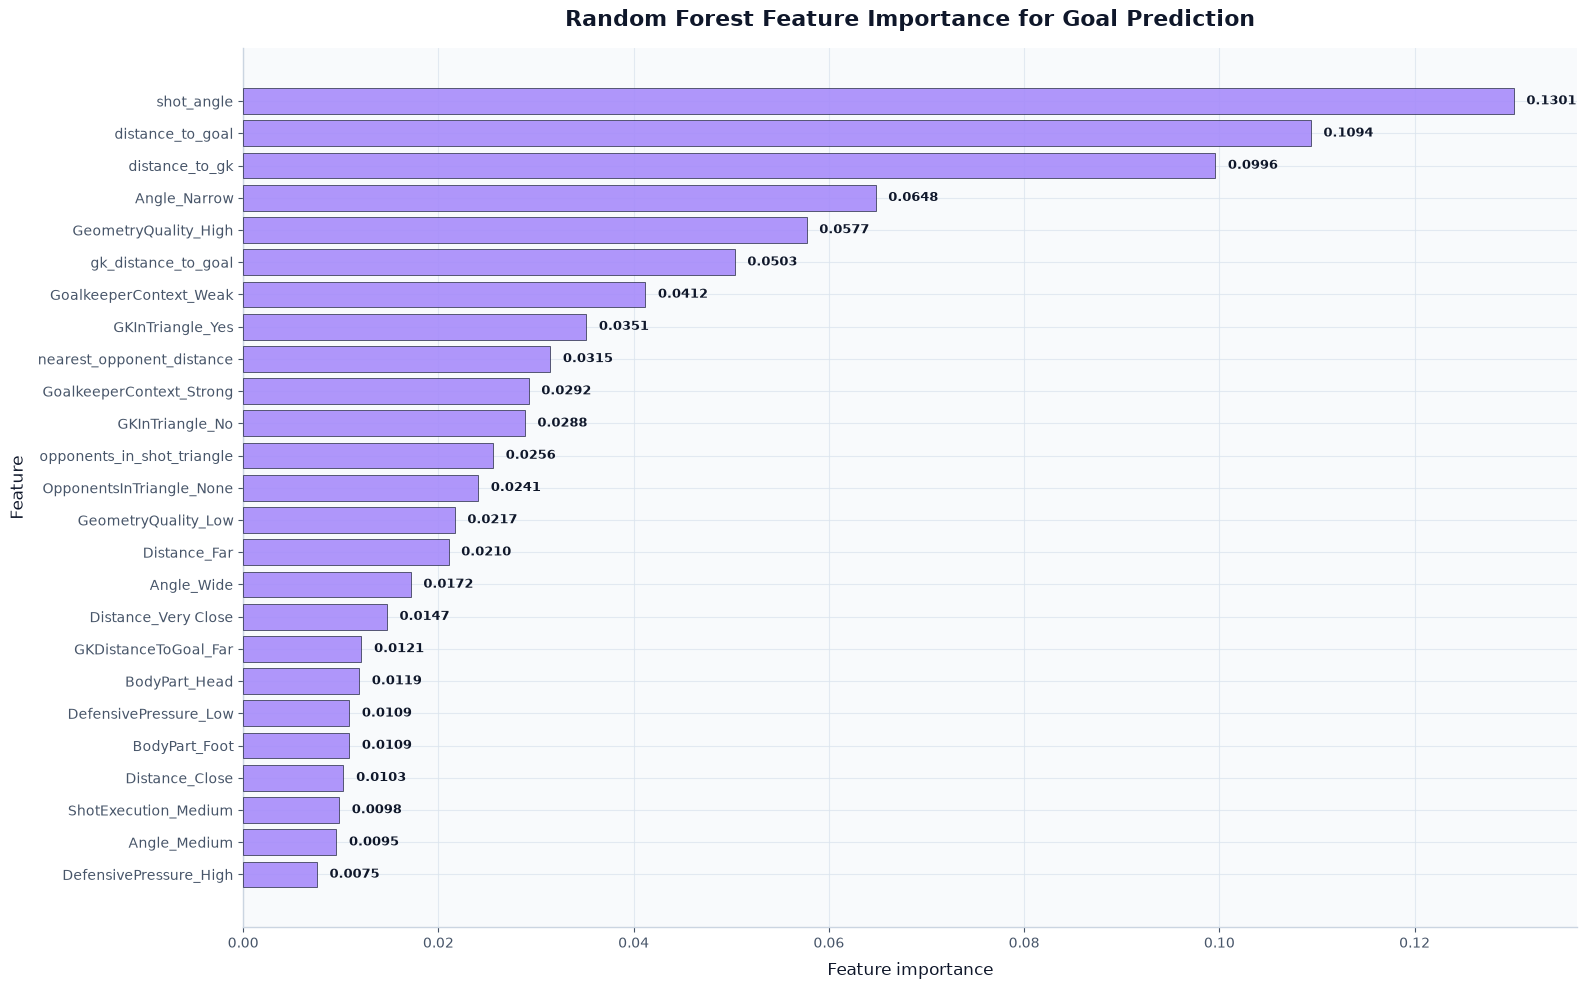

In [17]:
# Random Forest Feature Importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=30,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

onehot_feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = list(onehot_feature_names) + numeric_features
rf_importances = rf_model.named_steps["classifier"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

display(rf_importance_df.head(30))

top_n = 25
plot_df = rf_importance_df.head(top_n).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor(BG)

bars = ax.barh(
    plot_df["feature"],
    plot_df["importance"],
    color=PURPLE,
    edgecolor="#0f172a",
    linewidth=0.5,
    alpha=0.90,
    zorder=3
)

style_axis(
    ax,
    title="Random Forest Feature Importance for Goal Prediction",
    xlabel="Feature importance",
    ylabel="Feature"
)

for bar, value in zip(bars, plot_df["importance"]):
    ax.text(
        value + plot_df["importance"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color=TEXT
    )

plt.tight_layout()
save_fig("figures/random_forest_feature_importance.png")
plt.show()


## Logistic Regression xG Baseline

Logistic Regression is a common classical approach for expected-goals modeling.

It estimates:

\[
P(Goal = 1 \mid shot\ features)
\]

The output probability is interpreted as `logistic_xg`.

In [18]:
# Logistic Regression xG Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score
)

logistic_xg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=3000,
            solver="lbfgs"
        ))
    ]
)

logistic_xg_model.fit(X_train, y_train)

logistic_xg_test = logistic_xg_model.predict_proba(X_test)[:, 1]

logistic_results = {
    "Model": "Logistic Regression xG",
    "Brier Score": brier_score_loss(y_test, logistic_xg_test),
    "Log Loss": log_loss(y_test, np.clip(logistic_xg_test, 1e-6, 1 - 1e-6)),
    "ROC AUC": roc_auc_score(y_test, logistic_xg_test),
    "Average Precision": average_precision_score(y_test, logistic_xg_test),
    "Total predicted goals": logistic_xg_test.sum(),
    "Actual goals": y_test.sum()
}

logistic_results_df = pd.DataFrame([logistic_results])
display(logistic_results_df)


,Model,Brier Score,Log Loss,ROC AUC,Average Precision,Total predicted goals,Actual goals
0,Logistic Regression xG,0.077384,0.270201,0.812398,0.44224,2930.17575,2944


## Bayesian Network Data Preparation

Bayesian Networks with conditional probability tables require discrete variables.

This section creates the training and test datasets for the Bayesian Network models.

In [19]:
# Bayesian Network Data Preparation
bn_columns = [
    "Distance",
    "Angle",
    "GeometryQuality",
    "BodyPart",
    "ShotType",
    "Technique",
    "ShotExecution",
    "PlayPattern",
    "UnderPressure",
    "FirstTime",
    "OneOnOne",
    "OpenGoal",
    "GKInTriangle",
    "OpponentsNearShooter",
    "OpponentsInTriangle",
    "NearestOpponent",
    "GKDistanceToGoal",
    "DefensivePressure",
    "GoalkeeperContext",
    "is_goal"
]

bn_columns = [col for col in bn_columns if col in modeling_data.columns]

bn_full_data = modeling_data[bn_columns].copy()

bn_full_data["Goal"] = bn_full_data["is_goal"].map({
    0: "No",
    1: "Yes"
})

bn_full_data = bn_full_data.drop(columns=["is_goal"])

bn_train, bn_test = train_test_split(
    bn_full_data,
    test_size=0.25,
    random_state=42,
    stratify=bn_full_data["Goal"]
)

# Convert to string and clean
for col in bn_full_data.columns:
    bn_full_data[col] = bn_full_data[col].astype(str)

for col in bn_train.columns:
    bn_train[col] = bn_train[col].astype(str)
    bn_test[col] = bn_test[col].astype(str)

bn_full_data = bn_full_data.replace(["nan", "NaN", "None", "<NA>"], "Unknown")
bn_train = bn_train.replace(["nan", "NaN", "None", "<NA>"], "Unknown")
bn_test = bn_test.replace(["nan", "NaN", "None", "<NA>"], "Unknown")

# State names are taken from the full BN dataset to prevent unseen test categories
state_names = {}

for col in bn_full_data.columns:
    states = sorted(bn_full_data[col].unique().tolist())
    state_names[col] = states

    bn_train[col] = pd.Categorical(
        bn_train[col],
        categories=states,
        ordered=False
    )

    bn_test[col] = pd.Categorical(
        bn_test[col],
        categories=states,
        ordered=False
    )

print("BN train shape:", bn_train.shape)
print("BN test shape:", bn_test.shape)

for col, states in state_names.items():
    print(f"{col}: {states}")


BN train shape: (80880, 20)
BN test shape: (26960, 20)
Distance: ['Close', 'Far', 'Medium', 'Very Close']
Angle: ['Medium', 'Narrow', 'Very Narrow', 'Wide']
GeometryQuality: ['High', 'Low', 'Medium']
BodyPart: ['Foot', 'Head', 'Other']
ShotType: ['Free Kick', 'Open Play', 'Other', 'Penalty']
Technique: ['Half Volley', 'Normal', 'Other', 'Volley']
ShotExecution: ['Difficult', 'Medium', 'Stable']
PlayPattern: ['From Corner', 'From Counter', 'From Free Kick', 'From Throw In', 'Other', 'Regular Play']
UnderPressure: ['No', 'Yes']
FirstTime: ['No', 'Yes']
OneOnOne: ['No', 'Yes']
OpenGoal: ['No', 'Yes']
GKInTriangle: ['No', 'Yes']
OpponentsNearShooter: ['One', 'ThreePlus', 'Two', 'Unknown']
OpponentsInTriangle: ['One', 'ThreePlus', 'Two', 'Unknown']
NearestOpponent: ['Close', 'Far', 'Medium', 'Very Close']
GKDistanceToGoal: ['Advanced', 'Close', 'Far', 'On Line']
DefensivePressure: ['High', 'Low', 'Medium']
GoalkeeperContext: ['Strong', 'Weak']
Goal: ['No', 'Yes']


## Expert Bayesian Network Structure

This is a manually designed Bayesian Network based on football logic.

The main logic is:

- geometry affects chance quality;
- body part, technique, and first-time status affect shot execution;
- opponents and pressure affect defensive pressure;
- goalkeeper position affects goalkeeper context;
- these intermediate variables affect the final probability of `Goal`.

In [20]:
# Expert Bayesian Network Structure

from pgmpy.models import DiscreteBayesianNetwork

expert_edges = [
    # Geometry
    ("Distance", "GeometryQuality"),
    ("Angle", "GeometryQuality"),

    # Shot execution
    ("BodyPart", "ShotExecution"),
    ("Technique", "ShotExecution"),
    ("FirstTime", "ShotExecution"),

    # Defensive pressure
    ("UnderPressure", "DefensivePressure"),
    ("OpponentsNearShooter", "DefensivePressure"),
    ("OpponentsInTriangle", "DefensivePressure"),
    ("NearestOpponent", "DefensivePressure"),

    # Goalkeeper context
    ("GKInTriangle", "GoalkeeperContext"),
    ("GKDistanceToGoal", "GoalkeeperContext"),

    # Final goal probability
    ("GeometryQuality", "Goal"),
    ("ShotExecution", "Goal"),
    ("DefensivePressure", "Goal"),
    ("GoalkeeperContext", "Goal"),
    ("ShotType", "Goal"),
    ("PlayPattern", "Goal"),
    ("OneOnOne", "Goal"),
    ("OpenGoal", "Goal")
]

expert_bn_model = DiscreteBayesianNetwork(expert_edges)

print("Expert BN structure created.")
print("Nodes:", len(expert_bn_model.nodes()))
print("Edges:", len(expert_bn_model.edges()))

for edge in expert_bn_model.edges():
    print(edge)


Expert BN structure created.
Nodes: 20
Edges: 19
('Distance', 'GeometryQuality')
('GeometryQuality', 'Goal')
('Angle', 'GeometryQuality')
('BodyPart', 'ShotExecution')
('ShotExecution', 'Goal')
('Technique', 'ShotExecution')
('FirstTime', 'ShotExecution')
('UnderPressure', 'DefensivePressure')
('DefensivePressure', 'Goal')
('OpponentsNearShooter', 'DefensivePressure')
('OpponentsInTriangle', 'DefensivePressure')
('NearestOpponent', 'DefensivePressure')
('GKInTriangle', 'GoalkeeperContext')
('GoalkeeperContext', 'Goal')
('GKDistanceToGoal', 'GoalkeeperContext')
('ShotType', 'Goal')
('PlayPattern', 'Goal')
('OneOnOne', 'Goal')
('OpenGoal', 'Goal')


## Expert Bayesian Network Visualization

This section visualizes the expert-designed Bayesian Network.

It uses Graphviz. If Graphviz is not installed, install both the Python package and the system executable.

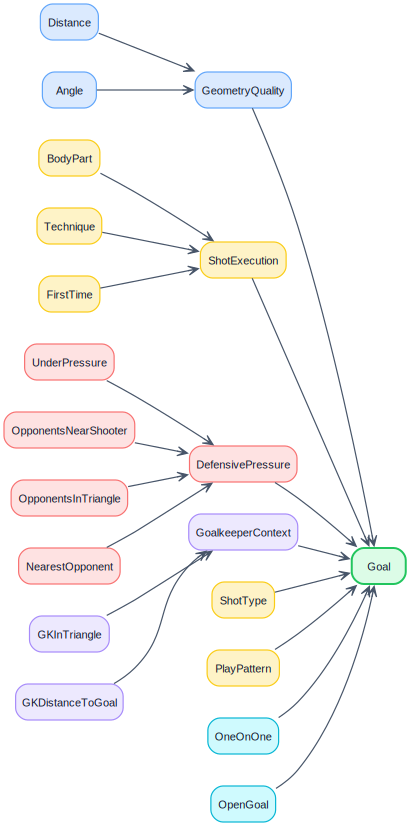

Expert BN structure saved: figures/expert_bn_xg_structure.png
Report copy saved: figures/expert_bn_structure.png


In [21]:
# Expert Bayesian Network Visualization

import graphviz
from IPython.display import display

dot = graphviz.Digraph(comment="BN-xG Expert Bayesian Network")

dot.attr(
    rankdir="LR",
    splines="spline",
    overlap="false",
    nodesep="0.45",
    ranksep="0.75",
    bgcolor="white"
)

dot.attr(
    "edge",
    color="#475569",
    arrowhead="vee",
    penwidth="1.2",
    fontname="Helvetica",
    fontsize="9"
)

geometry_nodes = ["Distance", "Angle", "GeometryQuality"]
execution_nodes = ["BodyPart", "Technique", "FirstTime", "ShotExecution", "ShotType", "PlayPattern"]
pressure_nodes = ["UnderPressure", "OpponentsNearShooter", "OpponentsInTriangle", "NearestOpponent", "DefensivePressure"]
goalkeeper_nodes = ["GKInTriangle", "GKDistanceToGoal", "GoalkeeperContext"]
special_nodes = ["OneOnOne", "OpenGoal"]
target_nodes = ["Goal"]

for node in expert_bn_model.nodes():

    if node in geometry_nodes:
        fillcolor = "#dbeafe"
        color = "#60a5fa"
    elif node in execution_nodes:
        fillcolor = "#fef3c7"
        color = "#facc15"
    elif node in pressure_nodes:
        fillcolor = "#fee2e2"
        color = "#f87171"
    elif node in goalkeeper_nodes:
        fillcolor = "#ede9fe"
        color = "#a78bfa"
    elif node in special_nodes:
        fillcolor = "#cffafe"
        color = "#06b6d4"
    elif node in target_nodes:
        fillcolor = "#dcfce7"
        color = "#22c55e"
    else:
        fillcolor = "#f1f5f9"
        color = "#cbd5e1"

    dot.node(
        node,
        node,
        shape="box",
        style="rounded,filled",
        fillcolor=fillcolor,
        color=color,
        fontcolor="#0f172a",
        fontname="Helvetica",
        fontsize="11",
        penwidth="2.0" if node == "Goal" else "1.2"
    )

for source, target in expert_bn_model.edges():
    dot.edge(source, target)

display(dot)

dot.render(
    filename="figures/expert_bn_xg_structure",
    format="png",
    cleanup=True
)

dot.render(
    filename="figures/expert_bn_structure",
    format="png",
    cleanup=True
)

print("Expert BN structure saved: figures/expert_bn_xg_structure.png")
print("Report copy saved: figures/expert_bn_structure.png")


## Expert Bayesian Network Parameter Learning

The BN structure is fixed, and the conditional probability tables are learned from training data.

Bayesian estimation with a BDeu prior is used to reduce instability from rare category combinations.

In [22]:
# Expert Bayesian Network Parameter Learning
from pgmpy.estimators import BayesianEstimator

expert_bn_model.fit(
    data=bn_train,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10,
    state_names=state_names
)

print("Expert BN CPDs learned.")
print("Expert BN valid:", expert_bn_model.check_model())
print("Number of CPDs:", len(expert_bn_model.get_cpds()))

important_cpds = [
    "Goal",
    "GeometryQuality",
    "ShotExecution",
    "DefensivePressure",
    "GoalkeeperContext"
]

for var in important_cpds:
    try:
        cpd = expert_bn_model.get_cpds(var)
        print("=" * 90)
        print("CPD of:", var)
        print(cpd)
    except Exception as e:
        print(f"Could not display CPD for {var}: {e}")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Distance': 'C', 'Angle': 'C', 'GeometryQuality': 'C', 'BodyPart': 'C', 'ShotType': 'C', 'Technique': 'C', 'ShotExecution': 'C', 'PlayPattern': 'C', 'UnderPressure': 'C', 'FirstTime': 'C', 'OneOnOne': 'C', 'OpenGoal': 'C', 'GKInTriangle': 'C', 'OpponentsNearShooter': 'C', 'OpponentsInTriangle': 'C', 'NearestOpponent': 'C', 'GKDistanceToGoal': 'C', 'DefensivePressure': 'C', 'GoalkeeperContext': 'C', 'Goal': 'C'}


Expert BN CPDs learned.
Expert BN valid: True
Number of CPDs: 20
CPD of: Goal
+-------------------+-----+---------------------------+
| DefensivePressure | ... | DefensivePressure(Medium) |
+-------------------+-----+---------------------------+
| GeometryQuality   | ... | GeometryQuality(Medium)   |
+-------------------+-----+---------------------------+
| GoalkeeperContext | ... | GoalkeeperContext(Weak)   |
+-------------------+-----+---------------------------+
| OneOnOne          | ... | OneOnOne(Yes)             |
+-------------------+-----+---------------------------+
| OpenGoal          | ... | OpenGoal(Yes)             |
+-------------------+-----+---------------------------+
| PlayPattern       | ... | PlayPattern(Regular Play) |
+-------------------+-----+---------------------------+
| ShotExecution     | ... | ShotExecution(Stable)     |
+-------------------+-----+---------------------------+
| ShotType          | ... | ShotType(Penalty)         |
+-------------------+-----

## Expert Bayesian Network Inference

Variable Elimination is used for exact probabilistic inference.

For each shot, the model estimates:

\[
BN\_xG = P(Goal = Yes \mid shot\ information)
\]

In [23]:
# Expert Bayesian Network Inference
from pgmpy.inference import VariableElimination
from tqdm.auto import tqdm

expert_inference = VariableElimination(expert_bn_model)

def predict_bn_probability(model, inference, row, target="Goal", positive_state="Yes"):
    evidence = {}

    for col in row.index:
        if col == target:
            continue
        if col in model.nodes():
            value = str(row[col])
            if value != "nan":
                evidence[col] = value

    query = inference.query(
        variables=[target],
        evidence=evidence,
        show_progress=False
    )

    states = list(query.state_names[target])
    yes_index = states.index(positive_state)

    return float(query.values[yes_index])

tqdm.pandas()

expert_bn_test_predictions = bn_test.copy()

expert_bn_test_predictions["expert_bn_xg"] = expert_bn_test_predictions.progress_apply(
    lambda row: predict_bn_probability(
        expert_bn_model,
        expert_inference,
        row
    ),
    axis=1
)

expert_bn_test_predictions["is_goal"] = expert_bn_test_predictions["Goal"].map({
    "No": 0,
    "Yes": 1
}).astype(int)

display(expert_bn_test_predictions[["Goal", "is_goal", "expert_bn_xg"]].head())


  0%|          | 0/26960 [00:00<?, ?it/s]

,Goal,is_goal,expert_bn_xg
82206,No,0,0.057365
36471,No,0,0.078224
10659,No,0,0.047416
54275,No,0,0.131584
10980,No,0,0.039230


## Hill-Climbing Bayesian Network Structure Learning

Hill Climbing is a structure-learning algorithm.

Instead of manually defining all edges, it searches for a graph structure that improves a scoring function such as BIC.

In [24]:
# Hill-Climbing Bayesian Network Structure Learning
from pgmpy.estimators import HillClimbSearch

hc_columns = [
    "Distance",
    "Angle",
    "GeometryQuality",
    "ShotExecution",
    "DefensivePressure",
    "GoalkeeperContext",
    "ShotType",
    "PlayPattern",
    "OneOnOne",
    "OpenGoal",
    "Goal"
]

hc_columns = [col for col in hc_columns if col in bn_train.columns]

hc_train = bn_train[hc_columns].copy()
hc_test = bn_test[hc_columns].copy()

# The scoring data must match the exact variables used by Hill-Climbing.
try:
    from pgmpy.estimators import BicScore
    scoring_method = BicScore(hc_train)
except Exception:
    from pgmpy.estimators import BIC
    scoring_method = BIC(hc_train)

hc = HillClimbSearch(hc_train)

learned_dag = hc.estimate(
    scoring_method=scoring_method,
    max_indegree=3,
    max_iter=1000
)

learned_edges = list(learned_dag.edges())

print("Hill Climbing structure learned.")
print("Number of learned edges:", len(learned_edges))

for edge in learned_edges:
    print(edge)

hill_bn_model = DiscreteBayesianNetwork(learned_edges)
hill_bn_model.add_nodes_from(hc_columns)

if "Goal" not in hill_bn_model.nodes():
    raise ValueError("The learned Hill-Climbing BN does not contain Goal.")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Distance': 'C', 'Angle': 'C', 'GeometryQuality': 'C', 'ShotExecution': 'C', 'DefensivePressure': 'C', 'GoalkeeperContext': 'C', 'ShotType': 'C', 'PlayPattern': 'C', 'OneOnOne': 'C', 'OpenGoal': 'C', 'Goal': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Distance': 'C', 'Angle': 'C', 'GeometryQuality': 'C', 'ShotExecution': 'C', 'DefensivePressure': 'C', 'GoalkeeperContext': 'C', 'ShotType': 'C', 'PlayPattern': 'C', 'OneOnOne': 'C', 'OpenGoal': 'C', 'Goal': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Distance': 'C', 'Angle': 'C', 'GeometryQuality': 'C', 'ShotExecution': 'C', 'DefensivePressure': 'C', 'GoalkeeperContext': 'C', 'ShotType': 'C', 'PlayPattern': 'C', 'OneOnOne': 'C', 'OpenGoal': 'C', 'Goal': 'C'}


  0%|          | 0/1000 [00:00<?, ?it/s]

Hill Climbing structure learned.
Number of learned edges: 26
('Distance', 'GeometryQuality')
('Distance', 'ShotExecution')
('Distance', 'Angle')
('Distance', 'Goal')
('Distance', 'PlayPattern')
('Distance', 'OneOnOne')
('Distance', 'OpenGoal')
('Distance', 'GoalkeeperContext')
('Angle', 'ShotExecution')
('Angle', 'GoalkeeperContext')
('Angle', 'Goal')
('GeometryQuality', 'Angle')
('GeometryQuality', 'ShotType')
('ShotExecution', 'PlayPattern')
('ShotExecution', 'ShotType')
('ShotExecution', 'OneOnOne')
('ShotExecution', 'DefensivePressure')
('GoalkeeperContext', 'ShotExecution')
('GoalkeeperContext', 'PlayPattern')
('GoalkeeperContext', 'OneOnOne')
('GoalkeeperContext', 'OpenGoal')
('ShotType', 'DefensivePressure')
('PlayPattern', 'ShotType')
('PlayPattern', 'DefensivePressure')
('Goal', 'GoalkeeperContext')
('Goal', 'OpenGoal')


## Hill-Climbing Bayesian Network Visualization

This graph shows the structure learned by the Hill-Climbing algorithm.

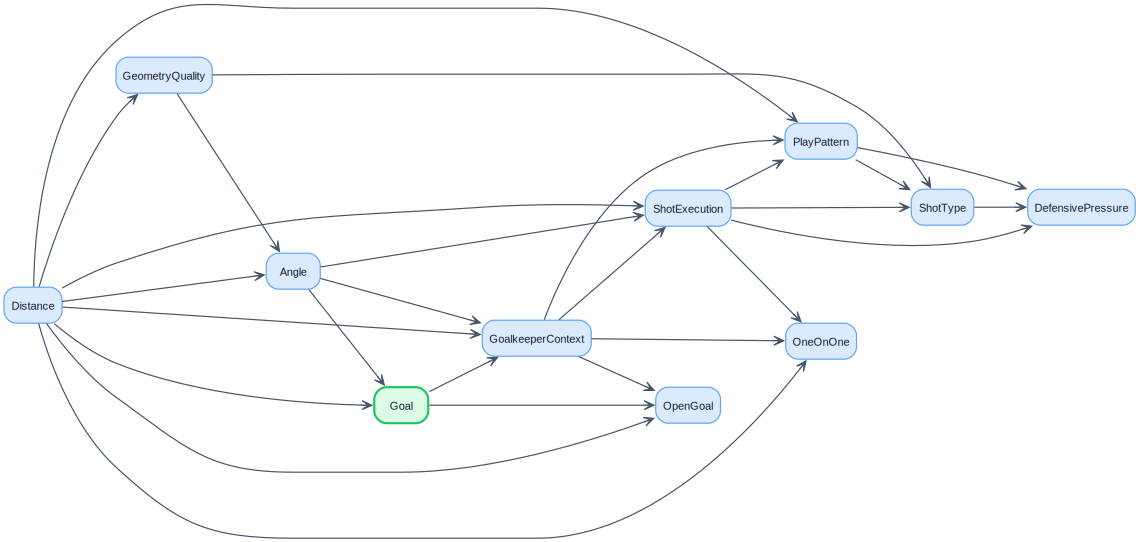

Hill-Climbing BN structure saved: figures/hill_climbing_bn_xg_structure.png
Report copy saved: figures/hill_climbing_bn_structure.png


In [25]:
# Hill-Climbing Bayesian Network Visualization
dot_hc = graphviz.Digraph(comment="Hill-Climbing Learned Bayesian Network")

dot_hc.attr(
    rankdir="LR",
    splines="spline",
    overlap="false",
    nodesep="0.45",
    ranksep="0.75",
    bgcolor="white"
)

dot_hc.attr(
    "edge",
    color="#475569",
    arrowhead="vee",
    penwidth="1.2",
    fontname="Helvetica",
    fontsize="9"
)

for node in hill_bn_model.nodes():
    if node == "Goal":
        fillcolor = "#dcfce7"
        color = "#22c55e"
        penwidth = "2.2"
    else:
        fillcolor = "#dbeafe"
        color = "#60a5fa"
        penwidth = "1.2"

    dot_hc.node(
        node,
        node,
        shape="box",
        style="rounded,filled",
        fillcolor=fillcolor,
        color=color,
        fontcolor="#0f172a",
        fontname="Helvetica",
        fontsize="11",
        penwidth=penwidth
    )

for source, target in hill_bn_model.edges():
    dot_hc.edge(source, target)

display(dot_hc)

dot_hc.render(
    filename="figures/hill_climbing_bn_xg_structure",
    format="png",
    cleanup=True
)

dot_hc.render(
    filename="figures/hill_climbing_bn_structure",
    format="png",
    cleanup=True
)

print("Hill-Climbing BN structure saved: figures/hill_climbing_bn_xg_structure.png")
print("Report copy saved: figures/hill_climbing_bn_structure.png")


## Hill-Climbing Bayesian Network Inference

After learning the structure, CPDs are learned and Variable Elimination is used to estimate the probability of a goal.

In [26]:
# Hill-Climbing Bayesian Network Inference
hc_state_names = {
    col: sorted(bn_full_data[col].astype(str).unique().tolist())
    for col in hc_columns
}

for col in hc_train.columns:
    hc_train[col] = pd.Categorical(
        hc_train[col].astype(str),
        categories=hc_state_names[col],
        ordered=False
    )
    hc_test[col] = pd.Categorical(
        hc_test[col].astype(str),
        categories=hc_state_names[col],
        ordered=False
    )

hill_bn_model.fit(
    data=hc_train,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10,
    state_names=hc_state_names
)

print("Hill-Climbing BN CPDs learned.")
print("Hill-Climbing BN valid:", hill_bn_model.check_model())

hill_inference = VariableElimination(hill_bn_model)

hill_bn_test_predictions = hc_test.copy()

hill_bn_test_predictions["hill_bn_xg"] = hill_bn_test_predictions.progress_apply(
    lambda row: predict_bn_probability(
        hill_bn_model,
        hill_inference,
        row
    ),
    axis=1
)

hill_bn_test_predictions["is_goal"] = hill_bn_test_predictions["Goal"].map({
    "No": 0,
    "Yes": 1
}).astype(int)

display(hill_bn_test_predictions[["Goal", "is_goal", "hill_bn_xg"]].head())


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Distance': 'C', 'Angle': 'C', 'GeometryQuality': 'C', 'ShotExecution': 'C', 'DefensivePressure': 'C', 'GoalkeeperContext': 'C', 'ShotType': 'C', 'PlayPattern': 'C', 'OneOnOne': 'C', 'OpenGoal': 'C', 'Goal': 'C'}


Hill-Climbing BN CPDs learned.
Hill-Climbing BN valid: True


  0%|          | 0/26960 [00:00<?, ?it/s]

,Goal,is_goal,hill_bn_xg
82206,No,0,0.048662
36471,No,0,0.254855
10659,No,0,0.048662
54275,No,0,0.146019
10980,No,0,0.083917


## Model Comparison without External Benchmark

The models are compared using probability-based metrics:

- Brier Score;
- Log Loss;
- ROC AUC;
- Average Precision.

In [27]:
# Model Comparison without External Benchmark
def evaluate_probability_model(y_true, y_pred, model_name):
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred_clipped = np.clip(y_pred, 1e-6, 1 - 1e-6)

    return {
        "Model": model_name,
        "Brier Score": brier_score_loss(y_true, y_pred),
        "Log Loss": log_loss(y_true, y_pred_clipped),
        "ROC AUC": roc_auc_score(y_true, y_pred),
        "Average Precision": average_precision_score(y_true, y_pred),
        "Actual Goals": int(np.sum(y_true)),
        "Total Expected Goals": float(np.sum(y_pred)),
        "Difference": float(np.sum(y_pred) - np.sum(y_true))
    }

comparison_rows = []

comparison_rows.append(
    evaluate_probability_model(
        y_test,
        logistic_xg_test,
        "Logistic Regression xG"
    )
)

comparison_rows.append(
    evaluate_probability_model(
        expert_bn_test_predictions["is_goal"],
        expert_bn_test_predictions["expert_bn_xg"],
        "Expert Bayesian Network xG"
    )
)

comparison_rows.append(
    evaluate_probability_model(
        hill_bn_test_predictions["is_goal"],
        hill_bn_test_predictions["hill_bn_xg"],
        "Hill-Climbing Bayesian Network xG"
    )
)

model_comparison_df = pd.DataFrame(comparison_rows)

display(model_comparison_df)


,Model,Brier Score,Log Loss,ROC AUC,Average Precision,Actual Goals,Total Expected Goals,Difference
0,Logistic Regression xG,0.077384,0.270201,0.812398,0.442240,2944,2930.175750,-13.824250
1,Expert Bayesian Network xG,0.081656,0.294899,0.771984,0.383319,2944,2944.570044,0.570044
2,Hill-Climbing Bayesian Network xG,0.083631,0.290873,0.770642,0.326843,2944,2936.370779,-7.629221


## StatsBomb xG External Benchmark

StatsBomb xG is used only as an external benchmark.

It is not used for training the Logistic Regression model or the Bayesian Network models.

In [28]:
# StatsBomb xG External Benchmark
if "statsbomb_xg" in modeling_data.columns:
    benchmark_df = modeling_data.loc[X_test.index].copy()
    benchmark_df["is_goal"] = y_test.values

    statsbomb_y_true = benchmark_df["is_goal"].astype(int)
    statsbomb_y_pred = benchmark_df["statsbomb_xg"].astype(float)

    statsbomb_result = evaluate_probability_model(
        statsbomb_y_true,
        statsbomb_y_pred,
        "StatsBomb xG Benchmark"
    )

    model_comparison_with_benchmark_df = pd.concat(
        [
            model_comparison_df,
            pd.DataFrame([statsbomb_result])
        ],
        ignore_index=True
    )

    display(model_comparison_with_benchmark_df)
else:
    model_comparison_with_benchmark_df = model_comparison_df.copy()
    print("statsbomb_xg column not found. Benchmark skipped.")


,Model,Brier Score,Log Loss,ROC AUC,Average Precision,Actual Goals,Total Expected Goals,Difference
0,Logistic Regression xG,0.077384,0.270201,0.812398,0.442240,2944,2930.175750,-13.824250
1,Expert Bayesian Network xG,0.081656,0.294899,0.771984,0.383319,2944,2944.570044,0.570044
2,Hill-Climbing Bayesian Network xG,0.083631,0.290873,0.770642,0.326843,2944,2936.370779,-7.629221
3,StatsBomb xG Benchmark,0.076644,0.269535,0.817333,0.449702,2944,2803.367256,-140.632744


## Model Comparison Visualization

This plot compares the models by Brier Score.

Lower Brier Score is better.

Saved figure: figures/model_comparison_brier_score.png


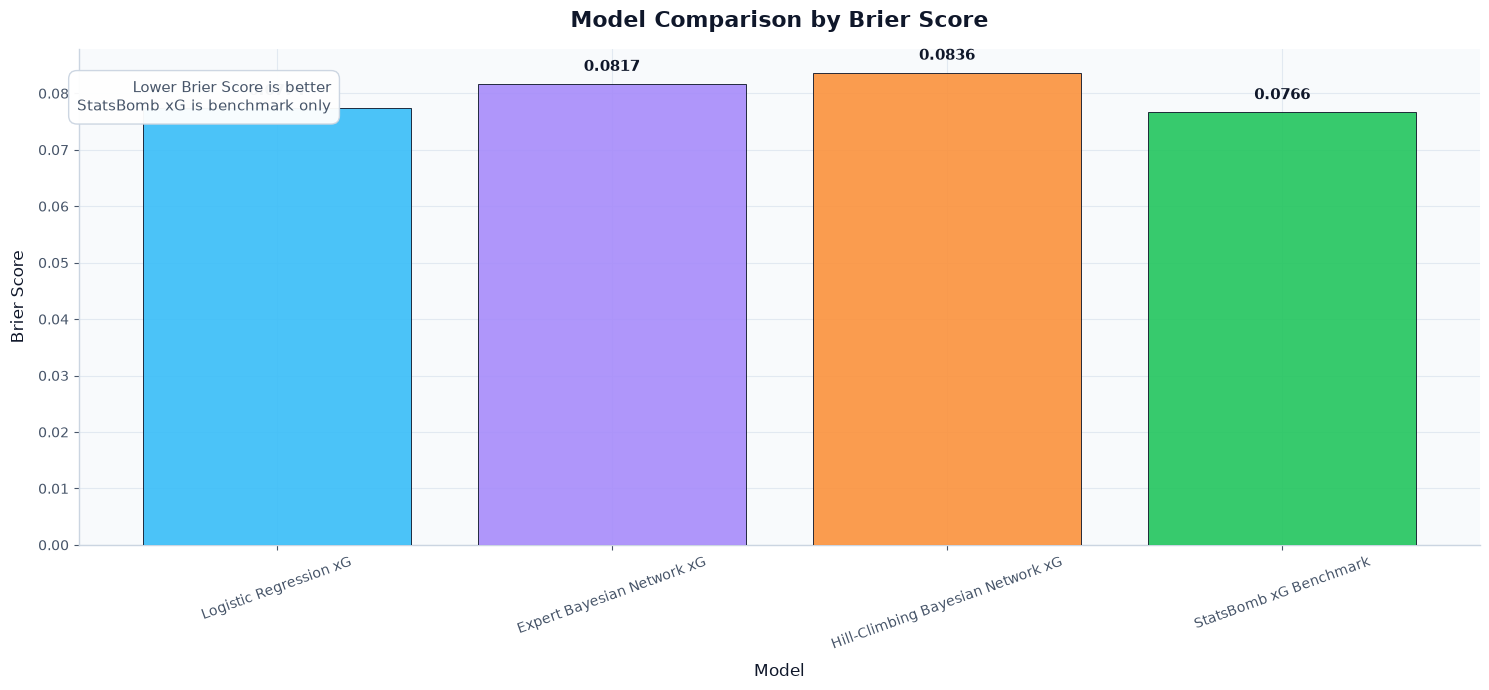

In [29]:
# Model Comparison Visualization
plot_df = model_comparison_with_benchmark_df.copy()

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor(BG)

colors = [BLUE, PURPLE, ORANGE, GREEN, RED]

bars = ax.bar(
    plot_df["Model"],
    plot_df["Brier Score"],
    color=colors[:len(plot_df)],
    edgecolor="#0f172a",
    linewidth=0.7,
    alpha=0.90,
    zorder=3
)

style_axis(
    ax,
    title="Model Comparison by Brier Score",
    xlabel="Model",
    ylabel="Brier Score"
)

ax.tick_params(axis="x", rotation=20)

for bar, value in zip(bars, plot_df["Brier Score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + plot_df["Brier Score"].max() * 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=TEXT
    )

ax.text(
    0.18,
    0.94,
    "Lower Brier Score is better\nStatsBomb xG is benchmark only",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    color=SUBTEXT,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=BORDER,
        alpha=0.96
    )
)

plt.tight_layout()
save_fig("figures/model_comparison_brier_score.png")
plt.show()


## Calibration Curve

A calibration curve compares predicted probabilities with observed goal rates.

A perfectly calibrated model follows the diagonal line.

Saved figure: figures/model_calibration_curve.png


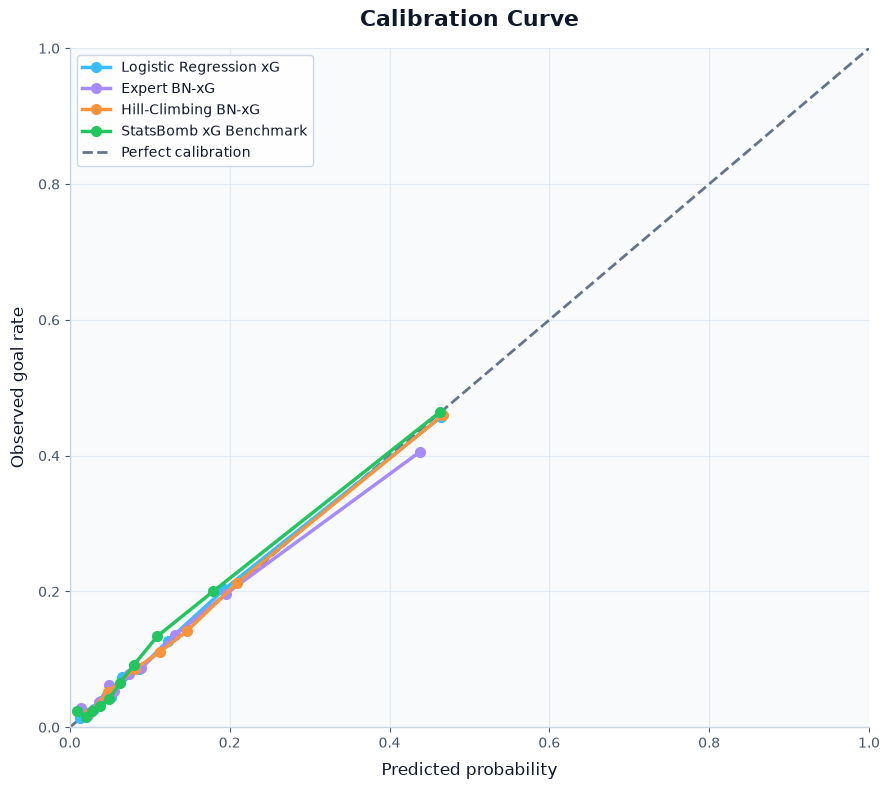

In [30]:
# Calibration Curve
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor(BG)

models_for_calibration = [
    ("Logistic Regression xG", y_test, logistic_xg_test, BLUE),
    ("Expert BN-xG", expert_bn_test_predictions["is_goal"], expert_bn_test_predictions["expert_bn_xg"], PURPLE),
    ("Hill-Climbing BN-xG", hill_bn_test_predictions["is_goal"], hill_bn_test_predictions["hill_bn_xg"], ORANGE)
]

if "statsbomb_xg" in modeling_data.columns:
    models_for_calibration.append(
        ("StatsBomb xG Benchmark", statsbomb_y_true, statsbomb_y_pred, GREEN)
    )

for model_name, true_values, pred_values, color in models_for_calibration:
    prob_true, prob_pred = calibration_curve(
        true_values,
        pred_values,
        n_bins=10,
        strategy="quantile"
    )

    ax.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=model_name,
        color=color,
        zorder=3
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#64748b",
    linewidth=2,
    label="Perfect calibration",
    zorder=2
)

style_axis(
    ax,
    title="Calibration Curve",
    xlabel="Predicted probability",
    ylabel="Observed goal rate"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
save_fig("figures/model_calibration_curve.png")
plt.show()


## Final Interpretation and Submission Notes

This notebook built and evaluated multiple expected-goals models:

- Logistic Regression xG baseline;
- Expert Bayesian Network xG;
- Hill-Climbing Bayesian Network xG;
- optional StatsBomb xG benchmark.

The Bayesian Network models also provide interpretable probabilistic structure, making them useful for explaining how shot geometry, execution, defensive pressure, and goalkeeper context affect the probability of scoring.

## Hill-Climbing Markov Blanket of Goal

The Markov blanket gives the local dependency neighborhood of `Goal` in the learned Hill-Climbing Bayesian Network. It contains the parents of `Goal`, the children of `Goal`, and the other parents of those children. Once the Markov blanket variables are known, `Goal` is conditionally independent from the rest of the network.

This section is useful for interpretation because the full learned graph may contain many edges, while the Markov blanket shows the variables that directly matter around the target node.

Parents of Goal: ['Distance', 'Angle']
Children of Goal: ['GoalkeeperContext', 'OpenGoal']
Spouses of Goal: ['Distance', 'Angle', 'GoalkeeperContext']
Full Markov blanket: ['Angle', 'Distance', 'GoalkeeperContext', 'OpenGoal']


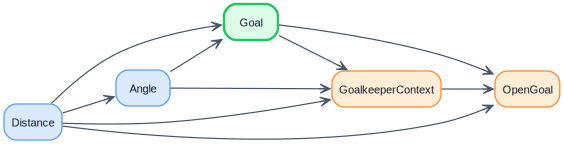

Markov blanket saved: figures/hill_climbing_goal_markov_blanket.png


In [31]:
# Hill-Climbing Markov Blanket of Goal
import graphviz

markov_target = "Goal"

if markov_target not in hill_bn_model.nodes():
    raise ValueError(f"{markov_target} is not present in the Hill-Climbing BN.")

mb_parents = list(hill_bn_model.get_parents(markov_target))
mb_children = list(hill_bn_model.get_children(markov_target))

mb_spouses = []
for child in mb_children:
    for parent in hill_bn_model.get_parents(child):
        if parent != markov_target and parent not in mb_spouses:
            mb_spouses.append(parent)

markov_blanket_goal = sorted(set(mb_parents + mb_children + mb_spouses))
mb_nodes = [markov_target] + markov_blanket_goal

print("Parents of Goal:", mb_parents)
print("Children of Goal:", mb_children)
print("Spouses of Goal:", mb_spouses)
print("Full Markov blanket:", markov_blanket_goal)

mb_edges = [
    (source, target)
    for source, target in hill_bn_model.edges()
    if source in mb_nodes and target in mb_nodes
]

dot_mb = graphviz.Digraph(comment="Hill-Climbing Markov Blanket of Goal")

dot_mb.attr(
    rankdir="LR",
    splines="spline",
    overlap="false",
    nodesep="0.45",
    ranksep="0.75",
    bgcolor="white"
)

dot_mb.attr(
    "edge",
    color="#475569",
    arrowhead="vee",
    penwidth="1.2",
    fontname="Helvetica",
    fontsize="9"
)

for node in mb_nodes:
    if node == markov_target:
        fillcolor = "#dcfce7"
        color = "#22c55e"
        penwidth = "2.4"
    elif node in mb_parents:
        fillcolor = "#dbeafe"
        color = "#60a5fa"
        penwidth = "1.4"
    elif node in mb_children:
        fillcolor = "#ffedd5"
        color = "#fb923c"
        penwidth = "1.4"
    elif node in mb_spouses:
        fillcolor = "#ede9fe"
        color = "#a78bfa"
        penwidth = "1.4"
    else:
        fillcolor = "#f1f5f9"
        color = "#94a3b8"
        penwidth = "1.2"

    dot_mb.node(
        node,
        node,
        shape="box",
        style="rounded,filled",
        fillcolor=fillcolor,
        color=color,
        fontcolor="#0f172a",
        fontname="Helvetica",
        fontsize="11",
        penwidth=penwidth
    )

for source, target in mb_edges:
    dot_mb.edge(source, target)

display(dot_mb)

dot_mb.render(
    filename="figures/hill_climbing_goal_markov_blanket",
    format="png",
    cleanup=True
)

print("Markov blanket saved: figures/hill_climbing_goal_markov_blanket.png")


### Markov Blanket Interpretation

The Markov blanket summarizes the local structure around the prediction target. In the learned Hill-Climbing BN, these variables are the closest statistical neighborhood of `Goal`. This should be interpreted as dependency discovery, not necessarily as causal football explanation, because Hill-Climbing optimizes a score over the data.

## Scenario Query Checks

The final query checks evaluate whether the Bayesian Networks behave according to football intuition. Instead of only comparing metric values, controlled football scenarios are queried with Variable Elimination. High-quality chances should receive higher probabilities, while difficult long-range or pressured shots should receive lower probabilities.

In [32]:
# Scenario Query Checks

def valid_states(model, variable):
    cpd = model.get_cpds(variable)
    if cpd is None:
        return []
    return list(cpd.state_names.get(variable, []))


def clean_query_evidence(model, evidence):
    cleaned = {}
    skipped = {}

    for variable, value in evidence.items():
        if variable not in model.nodes():
            skipped[variable] = "variable not in model"
            continue

        states = valid_states(model, variable)
        if states and value not in states:
            skipped[variable] = f"invalid state: {value}; valid states: {states}"
            continue

        cleaned[variable] = value

    return cleaned, skipped


def goal_probability(model, inference, evidence, goal_node="Goal", positive_state="Yes"):
    cleaned, skipped = clean_query_evidence(model, evidence)
    query = inference.query(
        variables=[goal_node],
        evidence=cleaned,
        show_progress=False
    )

    states = list(query.state_names[goal_node])
    if positive_state not in states:
        positive_state = states[-1]

    probability = float(query.values[states.index(positive_state)])
    return probability, cleaned, skipped


scenario_queries = {
    "Open goal chance": {
        "OpenGoal": "Yes",
        "Distance": "Very Close",
        "GeometryQuality": "High",
        "GoalkeeperContext": "Weak",
        "DefensivePressure": "Low",
        "OneOnOne": "Yes"
    },
    "High-quality close shot": {
        "Distance": "Very Close",
        "GeometryQuality": "High",
        "ShotExecution": "Strong",
        "DefensivePressure": "Low",
        "GoalkeeperContext": "Weak"
    },
    "Header from corner under pressure": {
        "ShotType": "Open Play",
        "PlayPattern": "From Corner",
        "BodyPart": "Head",
        "Distance": "Close",
        "DefensivePressure": "High"
    },
    "Difficult long-range shot": {
        "Distance": "Far",
        "GeometryQuality": "Low",
        "DefensivePressure": "High",
        "GoalkeeperContext": "Strong",
        "OpenGoal": "No",
        "OneOnOne": "No"
    }
}

scenario_rows = []

for scenario, evidence in scenario_queries.items():
    expert_probability, expert_used, expert_skipped = goal_probability(
        expert_bn_model,
        expert_inference,
        evidence
    )

    hill_probability, hill_used, hill_skipped = goal_probability(
        hill_bn_model,
        hill_inference,
        evidence
    )

    scenario_rows.append({
        "Scenario": scenario,
        "Expert BN xG": expert_probability,
        "Hill-Climbing BN xG": hill_probability,
        "Difference": expert_probability - hill_probability,
        "Expert evidence used": expert_used,
        "Hill evidence used": hill_used,
        "Expert skipped evidence": expert_skipped,
        "Hill skipped evidence": hill_skipped
    })

scenario_query_results_df = pd.DataFrame(scenario_rows)

scenario_query_display_df = scenario_query_results_df[
    ["Scenario", "Expert BN xG", "Hill-Climbing BN xG", "Difference"]
].copy()

for column in ["Expert BN xG", "Hill-Climbing BN xG", "Difference"]:
    scenario_query_display_df[column] = scenario_query_display_df[column].round(4)

display(scenario_query_display_df)

print("Detailed evidence check")
print("=" * 80)
for _, row in scenario_query_results_df.iterrows():
    print("\nScenario:", row["Scenario"])
    print("Expert evidence used:", row["Expert evidence used"])
    if row["Expert skipped evidence"]:
        print("Expert skipped evidence:", row["Expert skipped evidence"])
    print("Hill evidence used:", row["Hill evidence used"])
    if row["Hill skipped evidence"]:
        print("Hill skipped evidence:", row["Hill skipped evidence"])
    print("-" * 80)


,Scenario,Expert BN xG,Hill-Climbing BN xG,Difference
0,Open goal chance,0.8157,0.7434,0.0723
1,High-quality close shot,0.4338,0.5242,-0.0904
2,Header from corner under pressure,0.0852,0.1301,-0.0449
3,Difficult long-range shot,0.0536,0.0253,0.0283


Detailed evidence check

Scenario: Open goal chance
Expert evidence used: {'OpenGoal': 'Yes', 'Distance': 'Very Close', 'GeometryQuality': 'High', 'GoalkeeperContext': 'Weak', 'DefensivePressure': 'Low', 'OneOnOne': 'Yes'}
Hill evidence used: {'OpenGoal': 'Yes', 'Distance': 'Very Close', 'GeometryQuality': 'High', 'GoalkeeperContext': 'Weak', 'DefensivePressure': 'Low', 'OneOnOne': 'Yes'}
--------------------------------------------------------------------------------

Scenario: High-quality close shot
Expert evidence used: {'Distance': 'Very Close', 'GeometryQuality': 'High', 'DefensivePressure': 'Low', 'GoalkeeperContext': 'Weak'}
Expert skipped evidence: {'ShotExecution': "invalid state: Strong; valid states: ['Difficult', 'Medium', 'Stable']"}
Hill evidence used: {'Distance': 'Very Close', 'GeometryQuality': 'High', 'DefensivePressure': 'Low', 'GoalkeeperContext': 'Weak'}
Hill skipped evidence: {'ShotExecution': "invalid state: Strong; valid states: ['Difficult', 'Medium', 'Stable'

Saved figure: figures/bn_query_checks_comparison.png


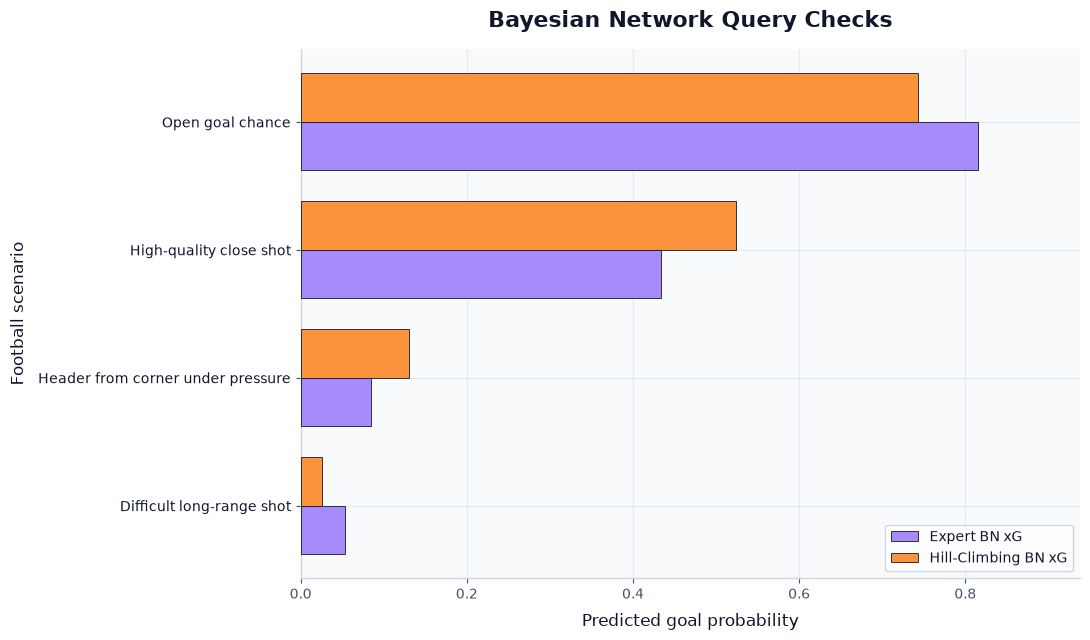

In [33]:
# Scenario Query Visualization
plot_df = scenario_query_display_df.sort_values("Expert BN xG", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

y_positions = np.arange(len(plot_df))
bar_height = 0.38

ax.barh(
    y_positions - bar_height / 2,
    plot_df["Expert BN xG"],
    height=bar_height,
    label="Expert BN xG",
    color=PURPLE,
    edgecolor="#0f172a",
    linewidth=0.6,
    zorder=3
)

ax.barh(
    y_positions + bar_height / 2,
    plot_df["Hill-Climbing BN xG"],
    height=bar_height,
    label="Hill-Climbing BN xG",
    color=ORANGE,
    edgecolor="#0f172a",
    linewidth=0.6,
    zorder=3
)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["Scenario"], fontsize=10, color=TEXT)

style_axis(
    ax,
    title="Bayesian Network Query Checks",
    xlabel="Predicted goal probability",
    ylabel="Football scenario"
)

ax.legend(loc="lower right", frameon=True, fontsize=10)
ax.set_xlim(0, max(plot_df["Expert BN xG"].max(), plot_df["Hill-Climbing BN xG"].max()) * 1.15)

plt.tight_layout()
save_fig("figures/bn_query_checks_comparison.png")
plt.show()


In [34]:
# ============================================================
# Model Behavior Analysis — Probability and Classification Metrics
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Collect model predictions in one clean dataframe
# ------------------------------------------------------------

model_prediction_frames = []

# Logistic Regression
if "logistic_xg_test" in globals():
    model_prediction_frames.append(
        pd.DataFrame({
            "model": "Logistic Regression",
            "y_true": np.array(y_test).astype(int),
            "y_prob": np.array(logistic_xg_test).astype(float)
        })
    )

# Expert BN
if "expert_bn_test_predictions" in globals():
    model_prediction_frames.append(
        pd.DataFrame({
            "model": "Expert BN",
            "y_true": expert_bn_test_predictions["is_goal"].astype(int).values,
            "y_prob": expert_bn_test_predictions["expert_bn_xg"].astype(float).values
        })
    )

# Hill-Climbing BN
if "hill_bn_test_predictions" in globals():
    model_prediction_frames.append(
        pd.DataFrame({
            "model": "Hill-Climbing BN",
            "y_true": hill_bn_test_predictions["is_goal"].astype(int).values,
            "y_prob": hill_bn_test_predictions["hill_bn_xg"].astype(float).values
        })
    )

# StatsBomb xG benchmark
if "statsbomb_y_true" in globals() and "statsbomb_y_pred" in globals():
    model_prediction_frames.append(
        pd.DataFrame({
            "model": "StatsBomb xG",
            "y_true": np.array(statsbomb_y_true).astype(int),
            "y_prob": np.array(statsbomb_y_pred).astype(float)
        })
    )

elif "modeling_data" in globals() and "statsbomb_xg" in modeling_data.columns:
    # Fallback if you have a test dataframe with statsbomb_xg
    if "test_data" in globals() and "statsbomb_xg" in test_data.columns:
        model_prediction_frames.append(
            pd.DataFrame({
                "model": "StatsBomb xG",
                "y_true": test_data["is_goal"].astype(int).values,
                "y_prob": test_data["statsbomb_xg"].astype(float).values
            })
        )

if len(model_prediction_frames) == 0:
    raise ValueError("No model prediction variables were found. Check variable names.")

all_model_predictions = pd.concat(model_prediction_frames, ignore_index=True)

# Remove invalid probabilities
all_model_predictions = all_model_predictions.replace([np.inf, -np.inf], np.nan)
all_model_predictions = all_model_predictions.dropna(subset=["y_true", "y_prob"])

# Clip probabilities for log loss safety
all_model_predictions["y_prob"] = all_model_predictions["y_prob"].clip(1e-6, 1 - 1e-6)

display(all_model_predictions.head())
print("Models found:", all_model_predictions["model"].unique())
print("Total prediction rows:", len(all_model_predictions))

,model,y_true,y_prob
0,Logistic Regression,0,0.021102
1,Logistic Regression,0,0.130781
2,Logistic Regression,0,0.060001
3,Logistic Regression,0,0.070110
4,Logistic Regression,0,0.054780


Models found: <ArrowStringArray>
['Logistic Regression', 'Expert BN', 'Hill-Climbing BN', 'StatsBomb xG']
Length: 4, dtype: str
Total prediction rows: 107840


In [35]:
# ============================================================
# Main Model Behavior Metrics
# ============================================================

def compute_model_metrics(y_true, y_prob, threshold=0.5):
    """
    Computes probability metrics and threshold-based classification metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "N": len(y_true),
        "Actual goals": int(y_true.sum()),
        "Actual goal rate": y_true.mean(),
        "Mean predicted xG": y_prob.mean(),
        "Total predicted xG": y_prob.sum(),
        "Total xG - actual goals": y_prob.sum() - y_true.sum(),

        # Probability metrics
        "Brier Score": brier_score_loss(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "MAE probability": mean_absolute_error(y_true, y_prob),
        "RMSE probability": np.sqrt(mean_squared_error(y_true, y_prob)),

        # Ranking metrics
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "Average Precision": average_precision_score(y_true, y_prob),

        # Threshold-based metrics
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),

        # Confusion matrix values
        "TN": confusion_matrix(y_true, y_pred).ravel()[0],
        "FP": confusion_matrix(y_true, y_pred).ravel()[1],
        "FN": confusion_matrix(y_true, y_pred).ravel()[2],
        "TP": confusion_matrix(y_true, y_pred).ravel()[3],
    }

    return metrics


metrics_rows = []

for model_name, group in all_model_predictions.groupby("model"):
    row = compute_model_metrics(
        y_true=group["y_true"].values,
        y_prob=group["y_prob"].values,
        threshold=0.5
    )
    row["Model"] = model_name
    metrics_rows.append(row)

model_behavior_metrics_df = pd.DataFrame(metrics_rows)

# Better column ordering
ordered_cols = [
    "Model", "N", "Actual goals", "Actual goal rate",
    "Mean predicted xG", "Total predicted xG", "Total xG - actual goals",
    "Brier Score", "Log Loss", "MAE probability", "RMSE probability",
    "ROC AUC", "Average Precision",
    "Threshold", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1",
    "TN", "FP", "FN", "TP"
]

model_behavior_metrics_df = model_behavior_metrics_df[ordered_cols]

display(
    model_behavior_metrics_df.style.format({
        "Actual goal rate": "{:.4f}",
        "Mean predicted xG": "{:.4f}",
        "Total predicted xG": "{:.2f}",
        "Total xG - actual goals": "{:.2f}",
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}",
        "MAE probability": "{:.4f}",
        "RMSE probability": "{:.4f}",
        "ROC AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
    })
)

,Model,N,Actual goals,Actual goal rate,Mean predicted xG,Total predicted xG,Total xG - actual goals,Brier Score,Log Loss,MAE probability,RMSE probability,ROC AUC,Average Precision,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Expert BN,26960,2944,0.1092,0.1092,2944.57,0.57,0.0817,0.2949,0.1601,0.2858,0.7720,0.3833,0.50,0.9005,0.5747,0.6961,0.1579,0.2575,23813,203,2479,465
1,Hill-Climbing BN,26960,2944,0.1092,0.1089,2936.37,-7.63,0.0836,0.2909,0.1666,0.2892,0.7706,0.3268,0.50,0.8942,0.5234,0.7347,0.0489,0.0917,23964,52,2800,144
2,Logistic Regression,26960,2944,0.1092,0.1087,2930.18,-13.82,0.0774,0.2702,0.1537,0.2782,0.8124,0.4422,0.50,0.9033,0.5954,0.6976,0.2014,0.3126,23759,257,2351,593
3,StatsBomb xG,26960,2944,0.1092,0.1040,2803.37,-140.63,0.0766,0.2695,0.1494,0.2768,0.8173,0.4497,0.50,0.9046,0.6013,0.7096,0.2133,0.3280,23759,257,2316,628
